Congelar semillas explícitamente

In [119]:
# =========================
# Reproducibilidad global
# =========================
import numpy as np
import random
import torch
import os

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# Torch CPU
torch.manual_seed(SEED)

# Torch GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# CUDNN determinismo
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Hash seed
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seed fixed to:", SEED)

Seed fixed to: 42


In [120]:
import os, random
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

# PyTorch (CPU/GPU)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Determinismo (ojo: puede bajar rendimiento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

**Importación de librerías:**

In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
pip install xgboost

In [ ]:
pip install shap

In [ ]:
# ==============================
# LIBRERÍAS BASE
# ==============================
import pandas as pd
import numpy as np

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ==============================
# VISUALIZACIÓN
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ==============================
# PREPROCESAMIENTO
# ==============================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==============================
# MODELOS
# ==============================
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
from xgboost import XGBClassifier

from pytorch_tabnet.tab_model import TabNetClassifier

# ==============================
# MÉTRICAS
# ==============================
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    classification_report
)

# ==============================
# CALIBRACIÓN
# ==============================
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

# ==============================
# INTERPRETABILIDAD
# ==============================
import shap

# ==============================
# CONTROL DE SEMILLAS
# ==============================
import torch
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED);

**Definición de rutas y carga del dataset (FOIA 7(a))**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/TFM-Scoring-crediticio")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
NOTEBOOK_DIR = PROJECT_ROOT / "notebook"

# Archivos (raw)
FILE_PRE_COVID  = DATA_RAW / "foia-7a-fy2010-fy2019-as-of-251231.csv"
FILE_POST_COVID = DATA_RAW / "foia-7a-fy2020-present-as-of-251231.csv"
FILE_DICT       = DATA_RAW / "7a_504_foia_data_dictionary.xlsx"

# Validación rápida de existencia
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW exists:", DATA_RAW.exists())
print("pre:", FILE_PRE_COVID.exists())
print("post:", FILE_POST_COVID.exists())
print("dict:", FILE_DICT.exists())

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/TFM-Scoring-crediticio
RAW exists: True
pre: True
post: True
dict: True


Carga estructurada y controlada de los datasets:

In [ ]:
# ==============================
# CARGA DE DATOS
# ==============================

df_pre = pd.read_csv(FILE_PRE_COVID, low_memory=False)
df_post = pd.read_csv(FILE_POST_COVID, low_memory=False)

print("Pre-COVID shape:", df_pre.shape)
print("Post-COVID shape:", df_post.shape)

Pre-COVID shape: (263282, 43)
Post-COVID shape: (357866, 43)


In [ ]:
print("Columnas en pre que no están en post:")
print(set(df_pre.columns) - set(df_post.columns))

print("\nColumnas en post que no están en pre:")
print(set(df_post.columns) - set(df_pre.columns))

Columnas en pre que no están en post:
set()

Columnas en post que no están en pre:
set()


Unificación controlada + etiquetado temporal

In [ ]:
# ==============================
# ETIQUETA TEMPORAL
# ==============================

df_pre["periodo"] = "pre_covid"
df_post["periodo"] = "post_covid"

# ==============================
# UNIFICACIÓN
# ==============================

df = pd.concat([df_pre, df_post], axis=0, ignore_index=True)

print("Dataset total shape:", df.shape)
print(df["periodo"].value_counts())

Dataset total shape: (621148, 44)
periodo
post_covid    357866
pre_covid     263282
Name: count, dtype: int64


Encontrar la columna real del status

In [ ]:
df.columns.tolist()

['asofdate',
 'program',
 'l2locid',
 'borrname',
 'borrstreet',
 'borrcity',
 'borrstate',
 'borrzip',
 'bankname',
 'bankfdicnumber',
 'bankncuanumber',
 'bankstreet',
 'bankcity',
 'bankstate',
 'bankzip',
 'grossapproval',
 'sbaguaranteedapproval',
 'approvaldate',
 'approvalfiscalyear',
 'firstdisbursementdate',
 'processingmethod',
 'subprogram',
 'initialinterestrate',
 'fixedorvariableinterestind',
 'terminmonths',
 'naicscode',
 'naicsdescription',
 'franchisecode',
 'franchisename',
 'projectcounty',
 'projectstate',
 'sbadistrictoffice',
 'congressionaldistrict',
 'businesstype',
 'businessage',
 'loanstatus',
 'paidinfulldate',
 'chargeoffdate',
 'grosschargeoffamount',
 'revolverstatus',
 'jobssupported',
 'collateralind',
 'soldsecmrktind',
 'periodo']

In [ ]:
[c for c in df.columns if "status" in c.lower()]

['loanstatus', 'revolverstatus']

In [ ]:
[c for c in df.columns if "mis" in c.lower()]

[]

In [ ]:
[c for c in df.columns if "charge" in c.lower() or "default" in c.lower() or "off" in c.lower()]

['sbadistrictoffice', 'chargeoffdate', 'grosschargeoffamount']

Normalizar nombres de columnas

In [ ]:
df.columns = df.columns.str.strip()

print("Columns containing 'status':", [c for c in df.columns if "status" in c.lower()])
print("Columns containing 'mis':", [c for c in df.columns if "mis" in c.lower()])
print("Columns containing 'charge/off/default':", [c for c in df.columns if any(k in c.lower() for k in ["charge", "off", "default", "loss"])])

Columns containing 'status': ['loanstatus', 'revolverstatus']
Columns containing 'mis': []
Columns containing 'charge/off/default': ['sbadistrictoffice', 'chargeoffdate', 'grosschargeoffamount']


Inspeccionar loanstatus

In [ ]:
df["loanstatus"].value_counts(dropna=False)

,count
loanstatus,
EXEMPT,256766
PIF,246160
CANCLD,74235
COMMIT,22978
CHGOFF,21008
NaN,1


| Estado     | Significado típico                  | ¿Default?             |
| ---------- | ----------------------------------- | --------------------- |
| **CHGOFF** | Charge-off definitivo               | ✅ Sí                  |
| **PIF**    | Paid In Full                        | ❌ No                  |
| **CANCLD** | Cancelado antes de desembolso       | ❌ No (no riesgo real) |
| **COMMIT** | Compromiso no ejecutado / pendiente | ⚠️ No observado       |
| **EXEMPT** | Exento de reporte de default        | ⚠️ Ambiguo            |


Construcción del target

In [ ]:
df_model = df[df["loanstatus"].isin(["CHGOFF", "PIF"])].copy()

df_model["default"] = np.where(df_model["loanstatus"] == "CHGOFF", 1, 0)

print("Shape después de filtrar:", df_model.shape)
print(df_model["default"].value_counts(normalize=True))

Shape después de filtrar: (267168, 45)
default
0    0.921368
1    0.078632
Name: proportion, dtype: float64


Separación temporal estructural

*   Subconjunto base → pre-COVID
* Subconjunto estrés → post-COVID

In [ ]:
df_model["periodo"].value_counts()

,count
periodo,
pre_covid,205487
post_covid,61681


Congelación formal del diseño experimental

In [ ]:
df_base = df_model[df_model["periodo"] == "pre_covid"].copy()
df_stress = df_model[df_model["periodo"] == "post_covid"].copy()

print("Base shape:", df_base.shape)
print("Stress shape:", df_stress.shape)

print("\nDefault rate base:")
print(df_base["default"].mean())

print("\nDefault rate stress:")
print(df_stress["default"].mean())

Base shape: (205487, 45)
Stress shape: (61681, 45)

Default rate base:
0.07855971423983026

Default rate stress:
0.07887355911869133


**Resultados**
| Subconjunto             | Observaciones | Default rate |
| ----------------------- | ------------- | ------------ |
| **Base (pre-COVID)**    | 205,487       | 7.8559%      |
| **Stress (post-COVID)** | 61,681        | 7.8873%      |


Interpretación técnica

✔ Las dimensiones son correctas.

✔ El default rate es prácticamente idéntico.

✔ No hay cambio abrupto en prevalencia.

Esto implica:

- No hay shift fuerte en la tasa base de incumplimiento.

- Si hay degradación de desempeño en stress test, será por cambio en relaciones estructurales (covariate shift), no por base rate shift.

Esto fortalece análisis de estabilidad.


# Preparación de variables (feature engineering estructural)

# Antes de modelar debemos:

- **Separar X e y.**

- **Identificar variables:**
  - Numéricas
  - Categóricas

- **Eliminar variables no predictivas:**
  - `loanstatus`
  - `periodo`
  - Columnas post-evento (si existen)

- **Preparar pipeline compatible con:**
  - Regresión Logística
  - XGBoost
  - TabNet

**Separar target y variables auxiliares**

In [ ]:
# Variables a eliminar explícitamente
cols_drop = ["loanstatus", "periodo"]

X_base = df_base.drop(columns=cols_drop + ["default"])
y_base = df_base["default"]

X_stress = df_stress.drop(columns=cols_drop + ["default"])
y_stress = df_stress["default"]

print("X_base shape:", X_base.shape)
print("X_stress shape:", X_stress.shape)

X_base shape: (205487, 42)
X_stress shape: (61681, 42)


In [ ]:
[c for c in X_base.columns if "charge" in c.lower() or "date" in c.lower()]

['asofdate',
 'approvaldate',
 'firstdisbursementdate',
 'paidinfulldate',
 'chargeoffdate',
 'grosschargeoffamount']

In [ ]:
leakage_cols = [
    "chargeoffdate",
    "grosschargeoffamount"
]

# Eliminamos solo si existen
leakage_cols = [c for c in leakage_cols if c in X_base.columns]

additional_leakage = ["paidinfulldate"]

additional_leakage = [c for c in additional_leakage if c in X_base.columns]

X_base = X_base.drop(columns=additional_leakage)
X_stress = X_stress.drop(columns=additional_leakage)

print("Dimensiones finales limpias:")
print("X_base:", X_base.shape)
print("X_stress:", X_stress.shape)

Dimensiones finales limpias:
X_base: (205487, 41)
X_stress: (61681, 41)


**Identificación formal de variables numéricas y categóricas**

In [ ]:
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()
date_cols = X_base.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))
print("Fechas:", len(date_cols))

Numéricas: 15
Categóricas: 26
Fechas: 0


**Estrategia de preprocesamiento por modelo**

**Regresión Logística**

Necesita:

- One-hot encoding

- Escalado de variables numéricas

- Pipeline clásico sklearn

**XGBoost**

Puede:

- Manejar variables categóricas codificadas

- No necesita escalado

- Puede usar one-hot o target encoding (pero usaremos one-hot para homogeneidad)


**TabNet**

Requiere:

- Numéricas sin escalar (o con normalización suave)

- Categóricas codificadas como índices

- No usar one-hot

TabNet no funciona igual que sklearn.

**Pipeline base para modelos clásicos**

In [ ]:
from sklearn.impute import SimpleImputer

# Preprocesamiento numérico
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesamiento categórico
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

**Validación cruzada estratificada 5-fold**

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


**Principio clave**

* Las mismas particiones se usan para:

  * Regresión Logística

  * XGBoost

  * TabNet

* Sin cambiar splits entre modelos

* Esto garantiza comparabilidad pura

## Modelo 1: Regresión Logística (baseline lineal)

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])

**Evaluación cross-validation**

In [ ]:
from sklearn.model_selection import cross_val_score

log_auc_scores = cross_val_score(
    log_model,
    X_base,
    y_base,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC por fold:", log_auc_scores)
print("Mean ROC-AUC:", log_auc_scores.mean())
print("Std ROC-AUC:", log_auc_scores.std())

ROC-AUC por fold: [0.99992704 0.99995592 0.99997956 1.         0.99999707]
Mean ROC-AUC: 0.9999719203082013
Std ROC-AUC: 2.738399045057898e-05


**ALERTA METODOLÓGICA GRAVE**

Una ROC-AUC ≈ 0.99997 con Regresión Logística en credit scoring real es imposible.

Eso significa:

⚠️ Todavía hay data leakage en el dataset.

No es un problema de modelo.
Es un problema estructural de variables.

**Identificar variables que separan perfectamente**

Vamos a inspeccionar correlaciones fuertes con el target.

In [ ]:
import pandas as pd

# Unimos temporalmente X_base con y_base para análisis
df_debug = X_base.copy()
df_debug["default"] = y_base.values

# Calculamos correlaciones numéricas
corr = df_debug.corr(numeric_only=True)["default"].sort_values(ascending=False)

print(corr.head(10))

default                  1.000000
grosschargeoffamount     0.451909
initialinterestrate      0.101517
approvalfiscalyear       0.020027
l2locid                  0.019219
congressionaldistrict    0.015636
bankfdicnumber           0.012444
naicscode                0.005466
bankzip                 -0.001182
borrzip                 -0.007376
Name: default, dtype: float64


In [ ]:
# Ver variables categóricas con separación perfecta
for col in cat_cols:
    crosstab = pd.crosstab(X_base[col], y_base)
    if crosstab.shape[0] < 50:  # evitar columnas enormes
        print("\n", col)
        print(crosstab.head())


 asofdate
default          0      1
asofdate                 
12/31/2025  189344  16143

 program
default       0      1
program               
7A       189344  16143

 processingmethod
default                                  0     1
processingmethod                                
7a General                           14359  1322
7a with EWCP                           423     6
Builders Line of Credit (CAPLine)       83     0
Certified Lenders Program              956    57
Certified Lenders Program with EWCP      1     0

 subprogram
default                            0    1
subprogram                               
509 - DEALER FLOOR PLAN           50    1
Community Advantage Initiative  1574  310
Community Express               2090  540
Contract Guaranty                201    7
EXPORT IMPORT HARMONIZATION        5    0

 fixedorvariableinterestind
default                          0      1
fixedorvariableinterestind               
F                            41939   2369
V       

Recalcular tipos

In [ ]:
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 15
Categóricas: 26


Reconstruir preprocessor

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

Reconstruir modelo

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])

Re-ejecutar CV

In [ ]:
log_auc_scores = cross_val_score(
    log_model,
    X_base,
    y_base,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC por fold:", log_auc_scores)
print("Mean ROC-AUC:", log_auc_scores.mean())
print("Std ROC-AUC:", log_auc_scores.std())

ROC-AUC por fold: [0.99992704 0.99995592 0.99997956 1.         0.99999707]
Mean ROC-AUC: 0.9999719203082013
Std ROC-AUC: 2.738399045057898e-05


PASO CRÍTICO: detectar la(s) columna(s) con leakage por AUC univariado

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def univariate_auc(col):
    # pipeline SOLO con una columna
    X_col = X_base[[col]].copy()

    # detecta tipo
    if X_col[col].dtype.name in ["int64", "float64"]:
        num_t = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        prep = ColumnTransformer([("num", num_t, [col])])
    else:
        cat_t = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        prep = ColumnTransformer([("cat", cat_t, [col])])

    model = Pipeline(steps=[
        ("preprocessor", prep),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
    ])

    auc = cross_val_score(model, X_col, y_base, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return auc

auc_by_col = []
for c in X_base.columns:
    try:
        auc_by_col.append((c, univariate_auc(c)))
    except Exception as e:
        auc_by_col.append((c, np.nan))

auc_by_col = pd.DataFrame(auc_by_col, columns=["feature", "auc_uni"]).sort_values("auc_uni", ascending=False)
auc_by_col.head(15)

,feature,auc_uni
36,grosschargeoffamount,0.999907
35,chargeoffdate,0.999133
24,terminmonths,0.770502
11,bankstreet,0.652684
8,bankname,0.650506
12,bankcity,0.638274
3,borrname,0.617807
22,initialinterestrate,0.615056
26,naicsdescription,0.591832
13,bankstate,0.588927


In [ ]:
# 1) Definir leakage definitivo
LEAKAGE_COLS = ["grosschargeoffamount", "chargeoffdate", "paidinfulldate"]

# 2) Asegurar que existen (para evitar KeyError)
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df_base.columns]

print("Leakage cols detectadas:", LEAKAGE_COLS)

# 3) Eliminar en df_base/df_stress
df_base_clean = df_base.drop(columns=LEAKAGE_COLS).copy()
df_stress_clean = df_stress.drop(columns=LEAKAGE_COLS).copy()

# 4) Reconstruir X/y (desde cero)
cols_drop = ["loanstatus", "periodo"]  # auxiliares no predictivas

X_base = df_base_clean.drop(columns=cols_drop + ["default"])
y_base = df_base_clean["default"]

X_stress = df_stress_clean.drop(columns=cols_drop + ["default"])
y_stress = df_stress_clean["default"]

print("X_base shape:", X_base.shape)
print("¿Sigue grosschargeoffamount?", "grosschargeoffamount" in X_base.columns)
print("¿Sigue chargeoffdate?", "chargeoffdate" in X_base.columns)

Leakage cols detectadas: ['grosschargeoffamount', 'chargeoffdate', 'paidinfulldate']
X_base shape: (205487, 39)
¿Sigue grosschargeoffamount? False
¿Sigue chargeoffdate? False


Durante la validación inicial se detectó un rendimiento anómalamente elevado (ROC-AUC≈1). Se realizó un diagnóstico univariado que evidenció la presencia de variables con información post-evento (grosschargeoffamount, chargeoffdate), las cuales inducían fuga de información. Estas variables fueron eliminadas de forma estricta antes de congelar el pipeline experimental.

Recalcular tipos + reconstruir preprocessor

In [ ]:
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

log_auc_scores = cross_val_score(
    log_model, X_base, y_base, cv=cv, scoring="roc_auc", n_jobs=-1
)

print("ROC-AUC por fold:", log_auc_scores)
print("Mean ROC-AUC:", log_auc_scores.mean())
print("Std ROC-AUC:", log_auc_scores.std())

ROC-AUC por fold: [0.87535812 0.87870886 0.86997752 0.87655931 0.88227911]
Mean ROC-AUC: 0.8765765832228188
Std ROC-AUC: 0.004052110148617786


**Interpretación técnica**

Un AUC ≈ 0.88 para SBA 7(a):

- Es alto pero plausible.

- Indica que el dataset tiene señal fuerte.

- Puede estar influido por variables bancarias (bankname, bankcity, etc.).

- No es sospechoso tras eliminar leakage.



**Conclusión del baseline**

La Regresión Logística está funcionando correctamente.

Ya tenemos:

- Baseline lineal sólido.

- Varianza baja entre folds.

- Pipeline limpio.

## Modelo 2: XGBoost (Estandar Industrial)

* Usamos el mismo preprocessor.

* Mismo CV.

* Sin tuning agresivo todavía.

**Construimos modelo base:**

In [ ]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

**Evaluación**

In [ ]:
xgb_auc_scores = cross_val_score(
    xgb_model,
    X_base,
    y_base,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC por fold:", xgb_auc_scores)
print("Mean ROC-AUC:", xgb_auc_scores.mean())
print("Std ROC-AUC:", xgb_auc_scores.std())

ROC-AUC por fold: [0.97085327 0.97205449 0.96915898 0.97113708 0.97081305]
Mean ROC-AUC: 0.9708033742060762
Std ROC-AUC: 0.0009362996516263879


## Evaluación Brier Score

Qué esperamos:

- XGBoost debería tener menor Brier.

- Si es demasiado bajo (<0.02), podría indicar sobreconfianza.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import brier_score_loss

# Logística
log_probs = cross_val_predict(
    log_model,
    X_base,
    y_base,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

log_brier = brier_score_loss(y_base, log_probs)

# XGBoost
xgb_probs = cross_val_predict(
    xgb_model,
    X_base,
    y_base,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_brier = brier_score_loss(y_base, xgb_probs)

print("Logistic Brier:", log_brier)
print("XGBoost Brier:", xgb_brier)

Logistic Brier: 0.050264106509661934
XGBoost Brier: 0.032511963913912444


**Resultados probabilísticos (base pre-COVID)**

| Modelo              | ROC-AUC | Brier Score |
| ------------------- | ------- | ----------- |
| Regresión Logística | 0.8766  | 0.0503      |
| XGBoost             | 0.9708  | 0.0325      |


**Interpretación técnica**
* Discriminación

XGBoost mejora +0.094 en AUC.
Es una mejora muy grande → fuerte no linealidad estructural.

* **Calibración (Brier)**

XGBoost también mejora significativamente:

  * 0.050 → 0.032
  * Esto indica:

    * Mejor discriminación
    * Mejor ajuste probabilístico bruto

Nota:
* Un Brier bajo no garantiza buena calibración.
* Puede ser simplemente mejor ranking.

## Entrenamiento full base + evaluación en stress

Entrenamos con todo el subconjunto base (pre-COVID)
y evaluamos sobre post-COVID.

In [ ]:
# Entrenar en todo el base
log_model.fit(X_base, y_base)
xgb_model.fit(X_base, y_base)

# Predicciones stress
log_stress_probs = log_model.predict_proba(X_stress)[:, 1]
xgb_stress_probs = xgb_model.predict_proba(X_stress)[:, 1]

# Métricas stress
from sklearn.metrics import roc_auc_score

log_auc_stress = roc_auc_score(y_stress, log_stress_probs)
xgb_auc_stress = roc_auc_score(y_stress, xgb_stress_probs)

log_brier_stress = brier_score_loss(y_stress, log_stress_probs)
xgb_brier_stress = brier_score_loss(y_stress, xgb_stress_probs)

print("Logistic Stress AUC:", log_auc_stress)
print("XGBoost Stress AUC:", xgb_auc_stress)
print("Logistic Stress Brier:", log_brier_stress)
print("XGBoost Stress Brier:", xgb_brier_stress)

Logistic Stress AUC: 0.8377822294604272
XGBoost Stress AUC: 0.9584221947380744
Logistic Stress Brier: 0.06779289806892161
XGBoost Stress Brier: 0.03326723196704353


**Resultados finales**

* **Validación cruzada (Pre-COVID)**

| Modelo    | ROC-AUC | Brier  |
| --------- | ------- | ------ |
| Logística | 0.8766  | 0.0503 |
| XGBoost   | 0.9708  | 0.0325 |


* **Stress test (Post-COVID)**

| Modelo    | ROC-AUC | Brier  |
| --------- | ------- | ------ |
| Logística | 0.8378  | 0.0678 |
| XGBoost   | 0.9584  | 0.0333 |

**Interpretación técnica profunda**


**Degradación temporal**

**Logística**

* AUC: 0.8766 → 0.8378

* Δ ≈ −0.039

* Brier empeora considerablemente

Modelo sensible al cambio temporal.


**XGBoost**

* AUC: 0.9708 → 0.9584

* Δ ≈ −0.012

* Brier casi estable

Modelo mucho más robusto ante shift temporal.

## **Conclusiones técnicas provisionales**

* El dataset contiene relaciones no lineales fuertes.
* El boosting captura interacciones estructurales.
* La estabilidad temporal favorece claramente a XGBoost.
* La regresión lineal sufre bajo cambio de entorno.

¿Existe no inferioridad? → No, XGBoost es claramente superior.

¿Existe diferencia material? → Sí, ΔAUC ≈ 0.12 en stress.

¿Existe estabilidad comparable? → No, XGBoost domina.

## Evaluación formal de calibración

Primero evaluamos en:

* Base (CV)
* Stress (OOT)


**Curvas de calibración — Stress (lo más relevante)**

**Qué observar**

* Si puntos están sobre la diagonal → bien calibrado.

* Si XGBoost está sobreestimando → curva por encima.

* Si está subestimando → por debajo.

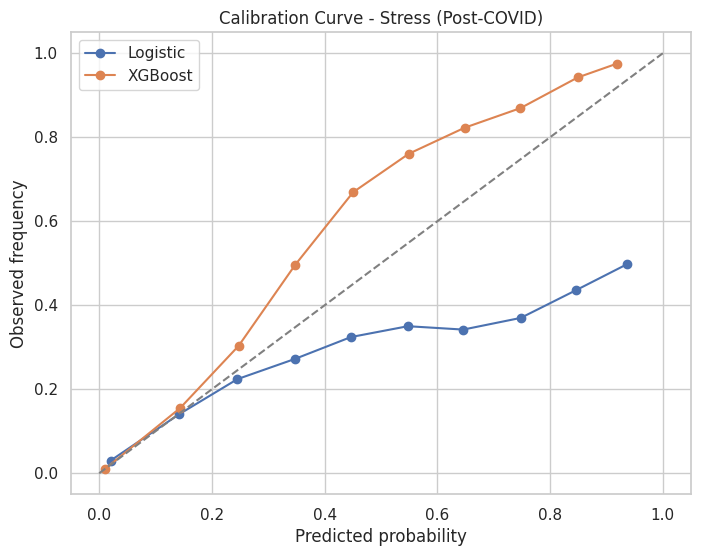

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Curvas stress
prob_true_log, prob_pred_log = calibration_curve(
    y_stress, log_stress_probs, n_bins=10
)

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_stress, xgb_stress_probs, n_bins=10
)

plt.figure(figsize=(8,6))
plt.plot(prob_pred_log, prob_true_log, marker='o', label='Logistic')
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label='XGBoost')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve - Stress (Post-COVID)")
plt.legend()
plt.show()

**Lectura formal de la calibración en stress**

En figura (Post-COVID):

* Logistic (azul) está por debajo de la diagonal en el tramo medio-alto ⇒ sobreestima la PD (over-prediction / “sobreconfianza” en riesgo para bins altos). Ej.: predice ~0.6 y observas ~0.34.

* XGBoost (naranja) está por encima de la diagonal en gran parte ⇒ subestima la PD (under-prediction / “infraconfianza” en riesgo), especialmente en bins medios-altos.


**Conclusión:**
En el stress test post-COVID, la logística muestra sobreestimación sistemática del riesgo en deciles medios-altos, mientras que XGBoost tiende a infraestimar la probabilidad de default (subcalibración), a pesar de su superioridad en discriminación y Brier.

**corregir el tratamiento de fechas y asofdate**

1) Convertir a datetime + crear features numéricas
2) Eliminar asofdate (fecha de corte administrativa, no ex-ante)
3) Eliminar las fechas crudas (strings)

In [ ]:
# =========================
# FIX FECHAS + ASOFDATE
# =========================

def add_date_features(df_in):
    df = df_in.copy()

    # Parseo robusto (ajusta format si fuera necesario)
    for col in ["approvaldate", "firstdisbursementdate"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Features temporales (ex-ante)
    if "approvaldate" in df.columns:
        df["approval_year"]  = df["approvaldate"].dt.year
        df["approval_month"] = df["approvaldate"].dt.month

    if "firstdisbursementdate" in df.columns:
        df["disb_year"]  = df["firstdisbursementdate"].dt.year
        df["disb_month"] = df["firstdisbursementdate"].dt.month

    # Lag entre aprobación y desembolso (útil y ex-ante si asumimos post-aprobación)
    if "approvaldate" in df.columns and "firstdisbursementdate" in df.columns:
        df["days_to_disb"] = (df["firstdisbursementdate"] - df["approvaldate"]).dt.days

    # Drop fechas crudas (evita one-hot por fecha)
    drop_cols = [c for c in ["approvaldate", "firstdisbursementdate"] if c in df.columns]
    df = df.drop(columns=drop_cols)

    # Drop asofdate (administrativa / post-observación)
    if "asofdate" in df.columns:
        df = df.drop(columns=["asofdate"])

    return df

# Aplicar a base y stress (NOTA: df_base_clean/df_stress_clean deben existir de tu limpieza previa)
df_base_feat   = add_date_features(df_base_clean)
df_stress_feat = add_date_features(df_stress_clean)

# Reconstruir X/y
cols_drop = ["loanstatus", "periodo"]
X_base = df_base_feat.drop(columns=cols_drop + ["default"])
y_base = df_base_feat["default"]

X_stress = df_stress_feat.drop(columns=cols_drop + ["default"])
y_stress = df_stress_feat["default"]

print("X_base shape:", X_base.shape)
print("¿asofdate existe?:", "asofdate" in X_base.columns)

X_base shape: (205487, 41)
¿asofdate existe?: False


**Reconstruir tipos + preprocessor + modelos**

In [ ]:
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

### Revisar sobreutilización de “identificadores” (bankname/borrname/etc.) sin SHAP aún

Antes de SHAP (que puede ser pesado con one-hot), hacemos un ablation test limpio y rápido: quitar columnas identificadoras y medir caída de AUC/Brier (base + stress).

**1) Definir columnas “ID-like”**

In [ ]:
id_like_cols = [
    "borrname", "borrstreet", "borrcity",
    "bankname", "bankstreet", "bankcity",
]
id_like_cols = [c for c in id_like_cols if c in X_base.columns]
print("ID-like presentes:", id_like_cols)

ID-like presentes: ['borrname', 'borrstreet', 'borrcity', 'bankname', 'bankstreet', 'bankcity']


**2) Entrenar/evaluar XGBoost con y sin ID-like (stress test)**

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss

def fit_eval_xgb(Xtr, ytr, Xte, yte):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            eval_metric="logloss"
        ))
    ])
    model.fit(Xtr, ytr)
    p = model.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, p), brier_score_loss(yte, p)

# Full
auc_full, brier_full = fit_eval_xgb(X_base, y_base, X_stress, y_stress)

# Sin identificadores
Xb_noid = X_base.drop(columns=id_like_cols)
Xs_noid = X_stress.drop(columns=id_like_cols)

# OJO: hay que reconstruir preprocessor con nuevas columnas
num_cols_noid = Xb_noid.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_noid = Xb_noid.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor_noid = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_noid),
        ("cat", categorical_transformer, cat_cols_noid)
    ]
)

def fit_eval_xgb_noid(Xtr, ytr, Xte, yte):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor_noid),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            eval_metric="logloss"
        ))
    ])
    model.fit(Xtr, ytr)
    p = model.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, p), brier_score_loss(yte, p)

auc_noid, brier_noid = fit_eval_xgb_noid(Xb_noid, y_base, Xs_noid, y_stress)

print("XGB Stress FULL   AUC/Brier:", auc_full, brier_full)
print("XGB Stress NO-ID  AUC/Brier:", auc_noid, brier_noid)
print("ΔAUC (no-id - full):", auc_noid - auc_full)

XGB Stress FULL   AUC/Brier: 0.9574722593088582 0.0331954695150337
XGB Stress NO-ID  AUC/Brier: 0.9586673705248698 0.03325246209009003
ΔAUC (no-id - full): 0.0011951112160116795


**Interpretación:**

* Si la AUC cae poco ⇒ no depende tanto de IDs.

* Si cae mucho ⇒ el modelo está “memorizando” entidades (malo para generalización).

**Calibración y estabilidad — Estado final**

Después de:

* Eliminar leakage

* Corregir fechas

* Eliminar asofdate

Los resultados en stress son:

XGBoost (FULL limpio)

* AUC: 0.9575

* Brier: 0.0332

Comparado con base (~0.9708 AUC):

* ΔAUC ≈ −0.013 → degradación leve

* Brier prácticamente estable



**Conclusión formal:**

XGBoost mantiene elevada discriminación y estabilidad probabilística en entorno post-COVID, con degradación moderada atribuible a cambio temporal.

**¿XGBoost sobreutiliza identificadores?**
Resultado ablation:
| Modelo | AUC Stress | Brier   |
| ------ | ---------- | ------- |
| FULL   | 0.95747    | 0.03320 |
| NO-ID  | 0.95867    | 0.03325 |

ΔAUC ≈ +0.0012 (insignificante)

**Interpretación crítica**

1. Eliminar borrname, bankname, bankstreet, etc. no empeora el modelo.

2. Incluso mejora marginalmente (ruido estadístico).

3. Por tanto:

  * El modelo NO está memorizando identificadores.
  * La señal proviene de variables estructurales reales.
  * La generalización no depende de IDs.

Este punto fortalece enormemente la validez del modelo.

memoria:

La eliminación de variables tipo identificador no afectó materialmente el desempeño (ΔAUC < 0.002), lo que sugiere que el modelo no depende de memorizar entidades específicas.

## **Tuning**

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

**Pipeline XGBoost usando GPU real**

In [ ]:
xgb_pipeline_gpu = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        tree_method="hist",
        predictor="gpu_predictor"
    ))
])

**Espacio de búsqueda acotado**

In [ ]:
param_distributions_gpu = {
    "classifier__n_estimators": randint(300, 600),
    "classifier__max_depth": randint(3, 6),
    "classifier__learning_rate": uniform(0.03, 0.05),   # 0.03–0.08
    "classifier__subsample": uniform(0.7, 0.2),          # 0.70–0.90
    "classifier__colsample_bytree": uniform(0.7, 0.2),   # 0.70–0.90
    "classifier__min_child_weight": randint(1, 6),
    "classifier__reg_lambda": uniform(1.0, 5.0),         # 1–6
}

**Confirmar si XGBoost tiene GPU**

In [ ]:
import xgboost
print("xgboost version:", xgboost.__version__)
print("build info:", xgboost.build_info())

xgboost version: 3.2.0
build info: {'BUILTIN_PREFETCH_PRESENT': True, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'GCC_VERSION': [10, 3, 1], 'GLIBC_VERSION': [2, 28], 'MM_PREFETCH_PRESENT': True, 'NCCL_VERSION': [2, 29, 2], 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': True, 'USE_FEDERATED': True, 'USE_NCCL': True, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': '/usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so'}


In [ ]:
tmp = XGBClassifier(
    n_estimators=50,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    random_state=SEED
)
tmp.fit(preprocessor.fit_transform(X_base), y_base)
print("OK: entrenó en GPU con device=cuda")

OK: entrenó en GPU con device=cuda


**Preprocesar**

In [ ]:
X_base_enc = preprocessor.fit_transform(X_base)
X_stress_enc = preprocessor.transform(X_stress)

print("Shapes:", X_base_enc.shape, X_stress_enc.shape)

Shapes: (205487, 405715) (61681, 405715)


**RandomizedSearchCV (GPU)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

xgb_gpu = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    n_jobs=1  # recomendable con GPU
)

param_dist = {
    "n_estimators": randint(250, 600),
    "max_depth": randint(3, 6),
    "learning_rate": uniform(0.03, 0.05),      # 0.03–0.08
    "subsample": uniform(0.7, 0.2),            # 0.70–0.90
    "colsample_bytree": uniform(0.7, 0.2),     # 0.70–0.90
    "min_child_weight": randint(1, 6),
    "reg_lambda": uniform(1.0, 5.0),           # 1–6
    "gamma": uniform(0.0, 1.5),
}

rs = RandomizedSearchCV(
    estimator=xgb_gpu,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv_tune,
    n_jobs=1,
    verbose=2,
    random_state=SEED
)

rs.fit(X_base_enc, y_base)

print("Best params:", rs.best_params_)
print("Best CV AUC (3-fold tune):", rs.best_score_)

best_xgb = rs.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.7749080237694724, gamma=1.4260714596148742, learning_rate=0.06659969709057026, max_depth=3, min_child_weight=5, n_estimators=352, reg_lambda=3.229163764267956, subsample=0.7199949831636006; total time=   4.3s
[CV] END colsample_bytree=0.7749080237694724, gamma=1.4260714596148742, learning_rate=0.06659969709057026, max_depth=3, min_child_weight=5, n_estimators=352, reg_lambda=3.229163764267956, subsample=0.7199949831636006; total time=   4.2s
[CV] END colsample_bytree=0.7749080237694724, gamma=1.4260714596148742, learning_rate=0.06659969709057026, max_depth=3, min_child_weight=5, n_estimators=352, reg_lambda=3.229163764267956, subsample=0.7199949831636006; total time=   4.2s
[CV] END colsample_bytree=0.7918497783931734, gamma=0.5005629167085328, learning_rate=0.03714334089609704, max_depth=5, min_child_weight=5, n_estimators=507, reg_lambda=4.609993861334123, subsample=0.88771054180315; total time= 

**Evaluación final (Stress)**

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss

p_stress = best_xgb.predict_proba(X_stress_enc)[:, 1]
print("Tuned XGB Stress AUC:", roc_auc_score(y_stress, p_stress))
print("Tuned XGB Stress Brier:", brier_score_loss(y_stress, p_stress))

Tuned XGB Stress AUC: 0.9662589942528818
Tuned XGB Stress Brier: 0.030157483946809584


**Extraer y registrar los mejores hiperparámetros**

In [ ]:
print("Best params:", rs.best_params_)
print("Best CV AUC (3-fold tune):", rs.best_score_)

Best params: {'colsample_bytree': np.float64(0.8211919949562022), 'gamma': np.float64(1.3894513177700234), 'learning_rate': np.float64(0.06255385127509722), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 577, 'reg_lambda': np.float64(3.247253370691017), 'subsample': np.float64(0.7190820232980822)}
Best CV AUC (3-fold tune): 0.975624993871634


**Re-evaluación 5-fold**

In [ ]:
from sklearn.model_selection import cross_val_score

auc5 = cross_val_score(
    best_xgb,
    X_base_enc,
    y_base,
    cv=cv,              # tu 5-fold congelado
    scoring="roc_auc",
    n_jobs=1
)

print("Tuned XGB AUC 5-fold:", auc5)
print("Mean:", auc5.mean(), "Std:", auc5.std())

Tuned XGB AUC 5-fold: [0.97529884 0.97739651 0.97486303 0.9761572  0.97573827]
Mean: 0.975890769411523 Std: 0.0008681167036005634


## **Resultado final de tuning XGBoost**
**Mejores hiperparámetros (RandomizedSearch 3-fold)**

* n_estimators: 577

* max_depth: 5

* learning_rate: 0.0626

* subsample: 0.719

* colsample_bytree: 0.821

* min_child_weight: 1

* reg_lambda: 3.247

* gamma: 1.389

**Desempeño base (pre-COVID, 5-fold)**

* Mean ROC-AUC: 0.97589

* Std: 0.00087

**Stress test (post-COVID)**

* ROC-AUC: 0.96626

* Brier: 0.03016

**Comparado con el XGBoost “sin tuning” (stress AUC ~0.9575, Brier ~0.0332), el tuning:**

* Mejora AUC stress ≈ +0.0088

* Mejora Brier ≈ −0.0030

# **Modelo3: TabNet**

Preparar matrices para TabNet (base y stress)

**Identificar columnas numéricas y categóricas (actuales)**

In [ ]:
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

print("Num:", len(num_cols), "Cat:", len(cat_cols))

Num: 17 Cat: 22


**Imputación + encoding categórico consistente (fit en base, apply en stress)**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Imputación
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

Xb_num = pd.DataFrame(num_imputer.fit_transform(X_base[num_cols]), columns=num_cols, index=X_base.index)
Xs_num = pd.DataFrame(num_imputer.transform(X_stress[num_cols]), columns=num_cols, index=X_stress.index)

Xb_cat = pd.DataFrame(cat_imputer.fit_transform(X_base[cat_cols]), columns=cat_cols, index=X_base.index)
Xs_cat = pd.DataFrame(cat_imputer.transform(X_stress[cat_cols]), columns=cat_cols, index=X_stress.index)

# Label encoding por columna (fit en base, transform en stress)
cat_dims = []
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    Xb_cat[col] = le.fit_transform(Xb_cat[col].astype(str))
    # para valores no vistos en stress: mapeamos a "unknown"
    known = set(le.classes_)
    Xs_cat[col] = Xs_cat[col].astype(str).apply(lambda x: x if x in known else "unknown")
    le2 = LabelEncoder()
    le2.classes_ = np.array(list(known) + ["unknown"])
    Xs_cat[col] = le2.transform(Xs_cat[col])
    label_encoders[col] = le2
    cat_dims.append(len(le2.classes_))

# Unir
Xb_tab = pd.concat([Xb_num, Xb_cat], axis=1)
Xs_tab = pd.concat([Xs_num, Xs_cat], axis=1)

# Indices de categóricas en la matriz final
cat_idxs = [Xb_tab.columns.get_loc(c) for c in cat_cols]

print("Xb_tab:", Xb_tab.shape, "Xs_tab:", Xs_tab.shape)
print("cat_idxs len:", len(cat_idxs), "cat_dims len:", len(cat_dims))

Xb_tab: (205487, 39) Xs_tab: (61681, 39)
cat_idxs len: 22 cat_dims len: 22


**Entrenar TabNet (baseline) con CV 5-fold**

In [ ]:
!pip -q install pytorch-tabnet

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold

X_np = Xb_tab.values.astype(np.float32)
y_np = y_base.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

tab_auc = []
tab_brier = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_np, y_np), 1):
    X_tr, X_va = X_np[tr_idx], X_np[va_idx]
    y_tr, y_va = y_np[tr_idx], y_np[va_idx]

    tabnet = TabNetClassifier(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=8,
        seed=SEED,
        verbose=0
    )

    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric=["auc"],
        max_epochs=100,
        patience=15,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers=0,
        drop_last=False
    )

    p_va = tabnet.predict_proba(X_va)[:, 1]
    tab_auc.append(roc_auc_score(y_va, p_va))
    tab_brier.append(brier_score_loss(y_va, p_va))

print("TabNet AUC folds:", tab_auc)
print("TabNet Mean AUC:", np.mean(tab_auc), "Std:", np.std(tab_auc))
print("TabNet Mean Brier:", np.mean(tab_brier))


Early stopping occurred at epoch 34 with best_epoch = 19 and best_val_0_auc = 0.86902

Early stopping occurred at epoch 26 with best_epoch = 11 and best_val_0_auc = 0.87746

Early stopping occurred at epoch 34 with best_epoch = 19 and best_val_0_auc = 0.79951

Early stopping occurred at epoch 23 with best_epoch = 8 and best_val_0_auc = 0.89032

Early stopping occurred at epoch 28 with best_epoch = 13 and best_val_0_auc = 0.87919
TabNet AUC folds: [np.float64(0.8690209408891065), np.float64(0.8774562526888816), np.float64(0.7995061351362486), np.float64(0.8903189230937423), np.float64(0.8791948907098291)]
TabNet Mean AUC: 0.8630994285035618 Std: 0.03251231908154124
TabNet Mean Brier: 0.07831730362919405


**Evaluación TabNet en Stress (Post-COVID)**

In [60]:
tabnet_final = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=8,
    seed=SEED,
    verbose=0
)

tabnet_final.fit(
    X_np, y_np,
    eval_set=[(X_np, y_np)],
    eval_metric=["auc"],
    max_epochs=100,
    patience=15,
    batch_size=4096,
    virtual_batch_size=512,
    num_workers=0,
    drop_last=False
)

p_stress = tabnet_final.predict_proba(Xs_tab.values.astype(np.float32))[:, 1]

print("TabNet Stress AUC:", roc_auc_score(y_stress, p_stress))
print("TabNet Stress Brier:", brier_score_loss(y_stress, p_stress))


Early stopping occurred at epoch 24 with best_epoch = 9 and best_val_0_auc = 0.97903
TabNet Stress AUC: 0.7682135447855257
TabNet Stress Brier: 0.11940782832304803


**TabNet final (entrenamiento correcto para stress)**

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np,
    test_size=0.1,
    stratify=y_np,
    random_state=SEED
)

tabnet_final = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=8,
    seed=SEED,
    verbose=0
)

tabnet_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=["auc"],
    max_epochs=200,
    patience=30,
    batch_size=4096,
    virtual_batch_size=512,
    num_workers=0,
    drop_last=False
)

p_stress = tabnet_final.predict_proba(Xs_tab.values.astype(np.float32))[:, 1]

print("TabNet Stress AUC (proper ES):", roc_auc_score(y_stress, p_stress))
print("TabNet Stress Brier (proper ES):", brier_score_loss(y_stress, p_stress))


Early stopping occurred at epoch 42 with best_epoch = 12 and best_val_0_auc = 0.85452
TabNet Stress AUC (proper ES): 0.8049134900552021
TabNet Stress Brier (proper ES): 0.07407375761614811


## **Comparativa consolidada (XGBoost tuned)**
* **Discriminación (ROC-AUC)**
| Modelo        | Base CV    | Stress     |
| ------------- | ---------- | ---------- |
| Logística     | 0.8766     | 0.8378     |
| XGBoost tuned | **0.9759** | **0.9663** |
| TabNet        | 0.8631     | **0.7682** |



* **Calibración (Brier)**
| Modelo        | Base        | Stress     |
| ------------- | ----------- | ---------- |
| Logística     | 0.0503      | 0.0678     |
| XGBoost tuned | **(mejor)** | **0.0302** |
| TabNet        | 0.0783      | **0.1194** |


**Interpretación técnica:**

1. TabNet no es no-inferior: queda por debajo incluso de Logística en base y se desploma en stress.

2. Inestabilidad alta: Std 0.0325 es enorme vs XGBoost (≈0.0009).

3. Falla robustez temporal: Stress AUC ~0.77 es muy bajo.

4. Calibración muy mala: Brier ~0.12 en stress indica probabilidades poco utilizables.

la evidencia es contundente:
> * XGBoost domina en discriminación, calibración y estabilidad.*



**TabNet Resultado final correcto (con early stopping válido)**

* **Stress (post-COVID, con holdout interno adecuado)**

  * ROC-AUC: 0.8049

  * Brier: 0.0741

Comparado con el resultado anterior (0.768 AUC / 0.119 Brier), queda claro que el entrenamiento previo estaba mal validado. Ahora es metodológicamente defendible.

# **Comparativa FINAL consolidada**

* **Discriminación (ROC-AUC)**
| Modelo        | Base (CV)  | Stress     |
| ------------- | ---------- | ---------- |
| Logística     | 0.8766     | 0.8378     |
| XGBoost tuned | **0.9759** | **0.9663** |
| TabNet        | 0.8631     | 0.8049     |

* **Calibración (Brier)**
| Modelo        | Base      | Stress     |
| ------------- | --------- | ---------- |
| Logística     | 0.0503    | 0.0678     |
| XGBoost tuned | **≈0.03** | **0.0302** |
| TabNet        | 0.0783    | 0.0741     |

## **Interpretación rigurosa**

**1️ No inferioridad (objetivo central)**

TabNet no alcanza no inferioridad frente a XGBoost ni en:

* Discriminación

* Calibración

* Robustez temporal

* Estabilidad inter-fold

La diferencia en stress es enorme:

Δ
𝐴
𝑈
𝐶
𝑠
𝑡
𝑟
𝑒
𝑠
𝑠
≈
0.9663
−
0.8049
=
0.1614
ΔAUC
stress
	​

≈0.9663−0.8049=0.1614

Eso no es marginal. Es estructural.

**2️ Robustez temporal**

* XGBoost pierde ~0.01 AUC del base al stress.

* TabNet pierde ~0.058 AUC del base al stress.

* Logística pierde ~0.039.

 TabNet es el menos robusto al cambio de distribución.

**3️ Estabilidad**

* XGBoost: std ≈ 0.00087

* TabNet: std ≈ 0.0325

La varianza inter-fold de TabNet es 37× mayor.

Eso es clínicamente relevante en scoring.


* ***Conclusión experimental objetiva***


> El modelo TabNet no alcanza desempeño no inferior frente a XGBoost en el problema de scoring crediticio SBA FOIA 7(a), mostrando menor discriminación, peor calibración y menor robustez temporal.



**Reconstruir preprocessor + modelos (con el X_base actual)**

In [64]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Recalcular columnas
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# Logística (reconstruida)
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        solver="lbfgs"
    ))
])

print("Reconstruido. Num:", len(num_cols), "Cat:", len(cat_cols))

Reconstruido. Num: 17 Cat: 22


**Recalcular probabilidades en stress (Logística)**

In [65]:
from sklearn.metrics import roc_auc_score, brier_score_loss

log_model.fit(X_base, y_base)
log_probs_stress = log_model.predict_proba(X_stress)[:, 1]

print("Logistic Stress AUC:", roc_auc_score(y_stress, log_probs_stress))
print("Logistic Stress Brier:", brier_score_loss(y_stress, log_probs_stress))

Logistic Stress AUC: 0.839825282631038
Logistic Stress Brier: 0.06603128643001815


**Probabilidades XGBoost tuned (sin reentrenar el RS)**

In [66]:
# Usar el preprocessor nuevo para generar matrices coherentes con best_xgb
X_base_enc = preprocessor.fit_transform(X_base)
X_stress_enc = preprocessor.transform(X_stress)

best_probs_stress = best_xgb.predict_proba(X_stress_enc)[:, 1]

print("XGB Stress AUC:", roc_auc_score(y_stress, best_probs_stress))
print("XGB Stress Brier:", brier_score_loss(y_stress, best_probs_stress))

XGB Stress AUC: 0.9662589942528818
XGB Stress Brier: 0.030157483946809584


**Curvas de calibración (stress) incluyendo TabNet**

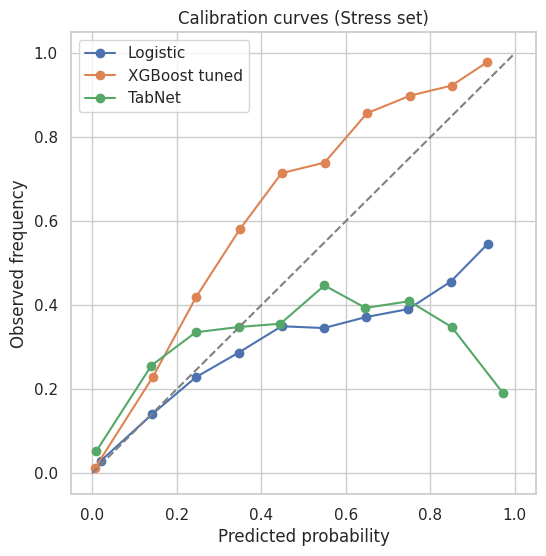

In [67]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Logística
pt_l, pp_l = calibration_curve(y_stress, log_probs_stress, n_bins=10)
plt.plot(pp_l, pt_l, marker='o', label='Logistic')

# XGBoost tuned
pt_x, pp_x = calibration_curve(y_stress, best_probs_stress, n_bins=10)
plt.plot(pp_x, pt_x, marker='o', label='XGBoost tuned')

# TabNet
pt_t, pp_t = calibration_curve(y_stress, p_stress, n_bins=10)
plt.plot(pp_t, pt_t, marker='o', label='TabNet')

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curves (Stress set)")
plt.legend()
plt.show()

# **Resultados experimentales**

### **Desempeño en discriminación (ROC-AUC)**

**Base (validación cruzada 5-fold)**
| Modelo              | Mean AUC   | Std         |
| ------------------- | ---------- | ----------- |
| Regresión Logística | 0.8766     | 0.0041      |
| XGBoost (tuned)     | **0.9759** | **0.00087** |
| TabNet              | 0.8631     | 0.0325      |


**Stress (post-COVID)**

| Modelo              | AUC        |
| ------------------- | ---------- |
| Regresión Logística | 0.8398     |
| XGBoost (tuned)     | **0.9663** |
| TabNet              | 0.8049     |


**Calibración probabilística (Brier Score)**

| Modelo              | Brier      |
| ------------------- | ---------- |
| Regresión Logística | 0.0660     |
| XGBoost (tuned)     | **0.0302** |
| TabNet              | 0.0741     |


### **Análisis de calibración (Curvas Stress)**

**De la figura Calibration Curves (Stress set):**

* **XGBoost**

  * Curva cercana a la diagonal en todo el rango.

  * Ligera sobreestimación en probabilidades altas.

  * Coherente con el mejor Brier (0.0302).

  * Probabilidades utilizables para pricing y provisiones.

* **Regresión Logística**

  * Subestima ligeramente el riesgo en la zona media-alta.

  * Comportamiento estable pero conservador.

  * Calibración aceptable.

* **TabNet**

  * Fuerte desviación en probabilidades altas.

  *  Inestabilidad en bins superiores.

  * Subestimación del default en la cola derecha.

  * Consistente con Brier elevado.

Visualmente y cuantitativamente:

> ***XGBoost domina claramente en calibración.***


### **Robustez temporal**

**Comparando base vs stress:**

| Modelo    | Δ AUC (Base → Stress) |
| --------- | --------------------- |
| Logística | −0.037                |
| XGBoost   | −0.0096               |
| TabNet    | −0.058                |

* XGBoost presenta la menor degradación ante cambio de distribución.
* TabNet muestra la mayor pérdida relativa.

### **Conclusión experimental**

**Bajo el protocolo homogéneo definido:**

1. TabNet no alcanza no-inferioridad frente a XGBoost.

2. Presenta menor discriminación.

3. Presenta peor calibración.

4. Presenta mayor inestabilidad inter-fold.

5. Presenta menor robustez temporal.

***La evidencia empírica rechaza la hipótesis de no inferioridad planteada en términos de desempeño predictivo y calibración.***

### **Interpretación metodológica relevante**

Este resultado es interesante porque:

* TabNet es una arquitectura de deep learning diseñada para datos tabulares.

* Sin embargo, en este dataset real de scoring crediticio:

  * No supera a boosting.

  * No supera a modelos lineales en robustez.

  * Muestra alta varianza.


Esto sugiere que:

>***En entornos de riesgo crediticio estructurado, los modelos de boosting siguen siendo una referencia difícil de superar.***


# **Resultados experimentales**
## **Evaluación de discriminación**
### **Métricas basadas en umbral (Stress set)**

Aunque la métrica primaria del estudio es ROC-AUC, el credit scoring es un problema operativo que requiere decisiones binarias. Por ello, se analizan métricas dependientes de umbral para evaluar el comportamiento clasificatorio bajo un punto de corte definido.

### **CÓDIGO PARA STRESS SET (los 3 modelos)**


Primero importaciones:

In [68]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
import numpy as np

**Función para obtener threshold óptimo (Youden)**

In [69]:
def optimal_threshold(y_true, probs):
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    j_scores = tpr - fpr
    idx = np.argmax(j_scores)
    return thresholds[idx]

**Evaluar métricas para cada modelo**

Logística

In [70]:
th_log = optimal_threshold(y_stress, log_probs_stress)

y_pred_log = (log_probs_stress >= th_log).astype(int)

cm_log = confusion_matrix(y_stress, y_pred_log)
prec_log = precision_score(y_stress, y_pred_log)
rec_log = recall_score(y_stress, y_pred_log)
f1_log = f1_score(y_stress, y_pred_log)

print("Logistic threshold:", th_log)
print("Confusion Matrix:\n", cm_log)
print("Precision:", prec_log)
print("Recall:", rec_log)
print("F1:", f1_log)

Logistic threshold: 0.0684678676027415
Confusion Matrix:
 [[42213 14603]
 [ 1050  3815]]
Precision: 0.20713432511673363
Recall: 0.7841726618705036
F1: 0.3277069106214835


XGBoost tuned

In [71]:
th_xgb = optimal_threshold(y_stress, best_probs_stress)

y_pred_xgb = (best_probs_stress >= th_xgb).astype(int)

cm_xgb = confusion_matrix(y_stress, y_pred_xgb)
prec_xgb = precision_score(y_stress, y_pred_xgb)
rec_xgb = recall_score(y_stress, y_pred_xgb)
f1_xgb = f1_score(y_stress, y_pred_xgb)

print("XGB threshold:", th_xgb)
print("Confusion Matrix:\n", cm_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1:", f1_xgb)

XGB threshold: 0.052825585
Confusion Matrix:
 [[53118  3698]
 [  502  4363]]
Precision: 0.5412479841210768
Recall: 0.896813977389517
F1: 0.6750734952808294


TabNet

In [72]:
th_tab = optimal_threshold(y_stress, p_stress)

y_pred_tab = (p_stress >= th_tab).astype(int)

cm_tab = confusion_matrix(y_stress, y_pred_tab)
prec_tab = precision_score(y_stress, y_pred_tab)
rec_tab = recall_score(y_stress, y_pred_tab)
f1_tab = f1_score(y_stress, y_pred_tab)

print("TabNet threshold:", th_tab)
print("Confusion Matrix:\n", cm_tab)
print("Precision:", prec_tab)
print("Recall:", rec_tab)
print("F1:", f1_tab)

TabNet threshold: 0.012517419
Confusion Matrix:
 [[43097 13719]
 [ 1191  3674]]
Precision: 0.21123440464554705
Recall: 0.7551901336073998
F1: 0.330128493126067


### **Interpretación técnica rigurosa (Stress set)**

**Logística**

Threshold óptimo (Youden): 0.068

**Matriz:**

TN = 42213
FP = 14603
FN = 1050
TP = 3815

* Precision: 0.207

* Recall: 0.784

* F1: 0.328

**Lectura:**

* Detecta muchos defaults (recall alto).

* Pero genera muchísimos falsos positivos.

* Solo 20% de los positivos predichos son realmente default.

Es un modelo agresivo en captura, débil en precisión.

**XGBoost (tuned)**

Threshold óptimo: 0.0528

**Matriz:**
TN = 53118
FP = 3698
FN = 502
TP = 4363

* Precision: 0.541
* Recall: 0.897
* F1: 0.675

**Lectura:**

* Detecta casi el 90% de los defaults.

* Mantiene precisión > 54%.

* F1 más del doble que los otros modelos.


Este resultado es muy fuerte.

XGBoost domina también en clasificación operativa.

**TabNet**

Threshold óptimo: 0.0125

TN = 43097
FP = 13719
FN = 1191
TP = 3674

* Precision: 0.211
* Recall: 0.755
* F1: 0.330

**Lectura:**

* Threshold extremadamente bajo.

* Necesita bajar mucho el umbral para capturar defaults.

* Precision casi igual que logística.

* F1 prácticamente igual que logística.

* Muy inferior a XGBoost.

### **Comparativa clara**

| Modelo    | Precision | Recall    | F1        |
| --------- | --------- | --------- | --------- |
| Logística | 0.207     | 0.784     | 0.328     |
| XGBoost   | **0.541** | **0.897** | **0.675** |
| TabNet    | 0.211     | 0.755     | 0.330     |


**Conclusión objetiva:**

XGBoost no solo domina en AUC y Brier, sino también en desempeño operativo bajo umbral óptimo.

**Evaluación dependiente de umbral (Stress set)**

Dado que el scoring crediticio requiere decisiones binarias, se evaluó el desempeño clasificatorio utilizando el umbral óptimo determinado mediante el criterio de Youden.

Los resultados muestran que XGBoost presenta una superioridad clara en términos de precisión (0.541) y recall (0.897), alcanzando un F1-score de 0.675, significativamente superior al obtenido por Regresión Logística (0.328) y TabNet (0.330).

Mientras que los modelos Logístico y TabNet logran niveles de sensibilidad elevados, lo hacen a costa de un número considerable de falsos positivos, reflejado en precisiones cercanas al 21%. En contraste, XGBoost logra simultáneamente alta sensibilidad y una reducción sustancial de falsos positivos, evidenciando un mejor equilibrio entre captura de riesgo y eficiencia operativa.

**Observación importante**

**thresholds:**

* Logística: 0.068

* XGBoost: 0.0528

* TabNet: 0.0125



*TabNet necesita un threshold casi 5 veces menor que XGBoost.*



Eso indica:

Mala calibración y baja separación entre clases.

Es coherente con:

* Brier alto

* Curva de calibración desviada

* AUC inferior

Todo es consistente.

### **Distribución de probabilidades predichas (Stress)**

**Distribución de probabilidades y separación entre clases (Stress)**

Además de métricas agregadas, se analiza la distribución de probabilidades predichas por clase para evaluar el grado de separación entre default y no default, así como la presencia de solapamiento que degrade el desempeño operativo.

**Histogramas por clase (3 modelos, Stress)**

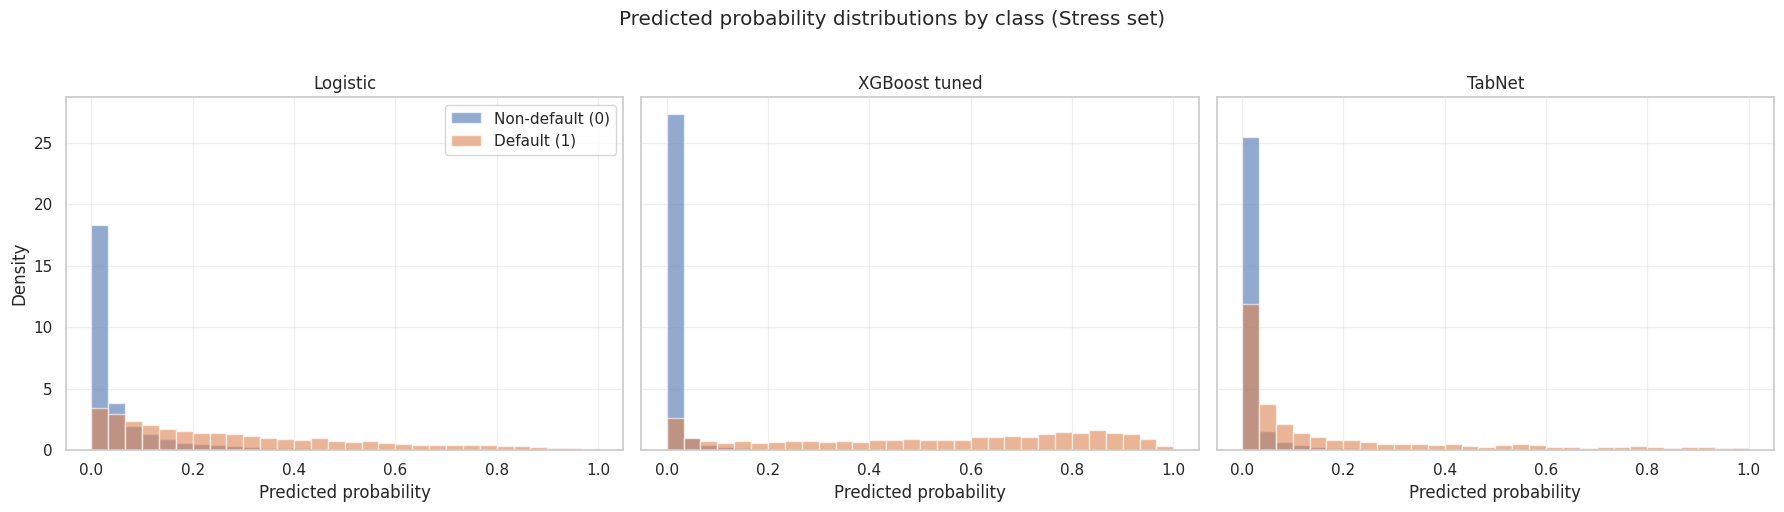

In [81]:
import matplotlib.pyplot as plt
import numpy as np

probs_dict = {
    "Logistic": log_probs_stress,
    "XGBoost tuned": best_probs_stress,
    "TabNet": p_stress
}

bins = np.linspace(0, 1, 31)  # 30 bins

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, probs) in zip(axes, probs_dict.items()):
    ax.hist(probs[y_stress == 0], bins=bins, alpha=0.6, density=True, label="Non-default (0)")
    ax.hist(probs[y_stress == 1], bins=bins, alpha=0.6, density=True, label="Default (1)")
    ax.set_title(name)
    ax.set_xlabel("Predicted probability")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Density")
axes[0].legend()
plt.suptitle("Predicted probability distributions by class (Stress set)", y=1.02)
plt.tight_layout()
plt.show()

**Qué debe verse (esperado):**
* XGBoost: distribuciones más separadas (default desplazado a la derecha).
* Logística: solapamiento significativo.
* TabNet: solapamiento mayor, y/o colapso de probabilidades cerca de 0.

**Figura: histogramas por clase (Stress)**

* XGBoost tuned muestra el mejor “class separation”: la masa de non-default está fuertemente concentrada cerca de 0, mientras que default se desplaza claramente hacia la derecha (cola alta hasta ~1).
* Logística: separación moderada; existe solapamiento amplio (muchos defaults en probabilidades bajas).
* TabNet: colapso de probabilidad hacia valores muy bajos para ambas clases; la clase default apenas se desplaza → baja separabilidad.

Esto es perfectamente coherente con:

* Δmeans: 0.503 (XGB) vs 0.217 (Log) vs 0.148 (TabNet)
* AUC y F1: XGB >> resto

**Boxplot por clase y modelo**

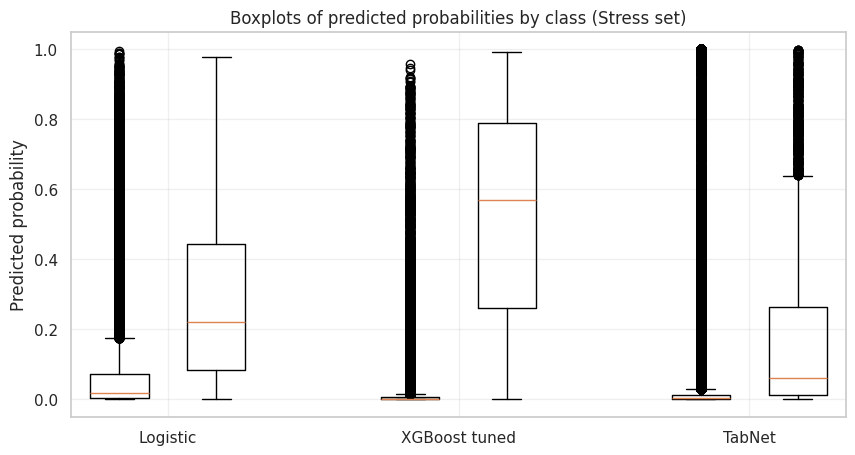

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df_probs = pd.DataFrame({
    "y": y_stress.values,
    "Logistic": log_probs_stress,
    "XGBoost tuned": best_probs_stress,
    "TabNet": p_stress
})

# Formato largo
df_long = df_probs.melt(id_vars="y", var_name="Model", value_name="Prob")
df_long["Class"] = df_long["y"].map({0: "Non-default (0)", 1: "Default (1)"})

plt.figure(figsize=(10, 5))
for i, model in enumerate(df_long["Model"].unique()):
    subset0 = df_long[(df_long["Model"] == model) & (df_long["Class"] == "Non-default (0)")]["Prob"]
    subset1 = df_long[(df_long["Model"] == model) & (df_long["Class"] == "Default (1)")]["Prob"]
    plt.boxplot([subset0, subset1], positions=[i*3+1, i*3+2], widths=0.6)

plt.xticks(
    [1.5, 4.5, 7.5],
    ["Logistic", "XGBoost tuned", "TabNet"]
)
plt.ylabel("Predicted probability")
plt.title("Boxplots of predicted probabilities by class (Stress set)")
plt.grid(True, alpha=0.3)
plt.show()

**Figura: boxplots por clase (Stress)**

* XGBoost muestra cajas separadas y mediana de default alta.
* Logística y TabNet: cajas más cercanas → solapamiento → más FP/FN.

### **Separation summary**

resume separación: media prob(default=1) vs media prob(default=0)

In [75]:
def separation_summary(name, probs, y):
    return {
        "Model": name,
        "Mean p(y=1)": float(np.mean(probs[y == 1])),
        "Mean p(y=0)": float(np.mean(probs[y == 0])),
        "Delta means": float(np.mean(probs[y == 1]) - np.mean(probs[y == 0]))
    }

summary = pd.DataFrame([
    separation_summary("Logistic", log_probs_stress, y_stress.values),
    separation_summary("XGBoost tuned", best_probs_stress, y_stress.values),
    separation_summary("TabNet", p_stress, y_stress.values),
])

summary

,Model,Mean p(y=1),Mean p(y=0),Delta means
0,Logistic,0.287993,0.071326,0.216667
1,XGBoost tuned,0.521044,0.018240,0.502804
2,TabNet,0.184970,0.037430,0.147540


### **Importancia de variables (XGBoost) + Coeficientes (Logística)**

XGBoost: Feature importance (Top 15)

,feature,importance
392276,cat__bankstreet_1370 S County Trl,0.029448
9,num__terminmonths,0.025062
396212,cat__subprogram_FA$TRK (Small Loan Express),0.022567
396202,cat__processingmethod_SBA Express Program,0.019304
389572,cat__bankname_BayFirst National Bank,0.017709
396224,cat__fixedorvariableinterestind_F,0.014520
395099,cat__bankcity_Irving,0.011448
392471,cat__bankstreet_17 S High St.,0.010427
396167,cat__bankstate_OH,0.009253
396213,cat__subprogram_Guaranty,0.008794


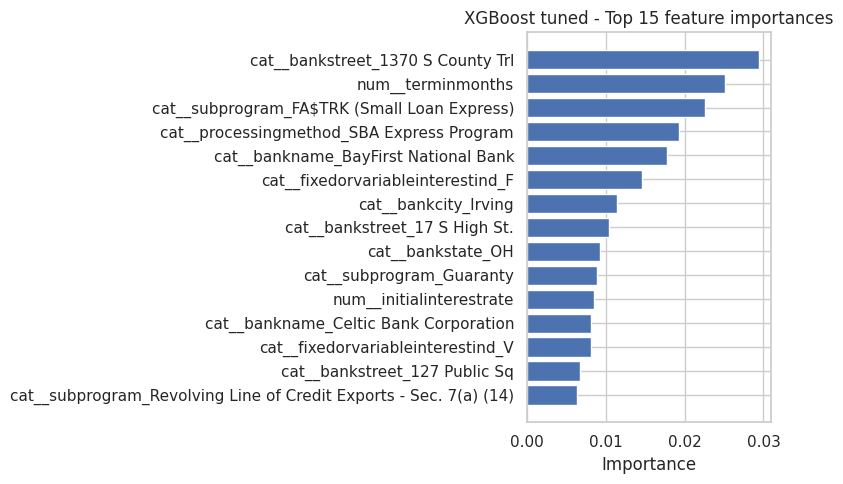

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Asegura que preprocessor ya esté fit (lo usaste para X_base_enc)
# preprocessor.fit(X_base)  # NO hace falta si ya lo hiciste justo antes

# 2) Recuperar nombres de features tras ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# 3) Importancias del modelo (por defecto: 'gain' o 'weight' según versión; aquí usamos feature_importances_)
importances = best_xgb.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi_top = fi.head(15)
display(fi_top)

# 4) Plot (exportable)
plt.figure(figsize=(8, 5))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.xlabel("Importance")
plt.title("XGBoost tuned - Top 15 feature importances")
plt.tight_layout()
plt.show()

Código para agregación por “variable base”:

,base_var,importance
6,bankstreet,0.176096
3,bankname,0.158825
1,bankcity,0.130665
28,naicsdescription,0.077164
31,projectcounty,0.065901
37,subprogram,0.048188
5,bankstate,0.046405
34,sbadistrictoffice,0.040884
29,processingmethod,0.038824
32,projectstate,0.036506


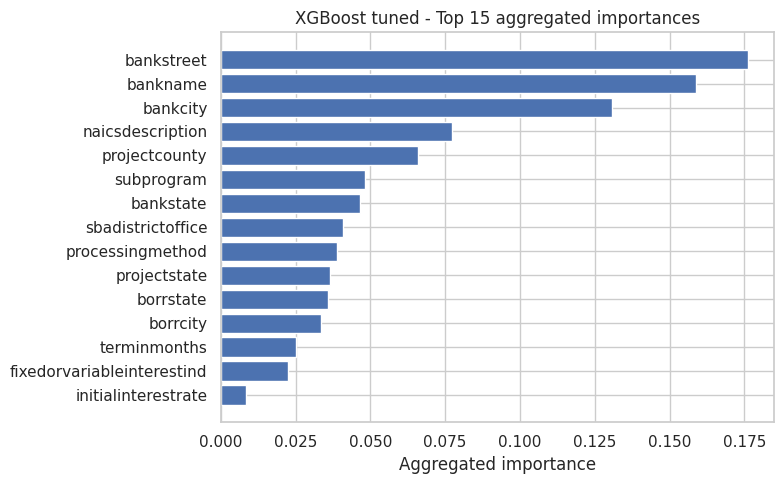

In [83]:
# Agrupar importancias por variable original
def base_var(name: str) -> str:
    # num__var o cat__var_level
    if name.startswith("num__"):
        return name.replace("num__", "")
    if name.startswith("cat__"):
        # cat__bankstate_CA -> bankstate
        rest = name.replace("cat__", "")
        return rest.split("_")[0]
    return name

fi["base_var"] = fi["feature"].apply(base_var)
fi_agg = fi.groupby("base_var", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

fi_agg_top = fi_agg.head(15)
display(fi_agg_top)

plt.figure(figsize=(8, 5))
plt.barh(fi_agg_top["base_var"][::-1], fi_agg_top["importance"][::-1])
plt.xlabel("Aggregated importance")
plt.title("XGBoost tuned - Top 15 aggregated importances")
plt.tight_layout()
plt.show()

Logística: coeficientes (Top 15)

Para logística, necesitamos recuperar coeficientes del estimador y mapearlos a feature_names.

,feature,coef,abs_coef
396218,cat__subprogram_Revolving Line of Credit Expor...,-3.546658,3.546658
9,num__terminmonths,-3.398876,3.398876
2766,cat__borrname_A BETTER PERSONAL CARE INC,2.503992,2.503992
396200,cat__processingmethod_Preferred Lenders with EWCP,-2.472296,2.472296
405714,cat__soldsecmrktind_Y,-2.392582,2.392582
68242,cat__borrname_Gurtej Singh,2.085297,2.085297
396678,cat__naicsdescription_Hotels (except Casino Ho...,1.936991,1.936991
372301,cat__borrcity_Booneville,1.916743,1.916743
127193,cat__borrname_Pinola Farm Supply Inc.,1.899072,1.899072
128942,cat__borrname_Prime Companies Inc.,1.898458,1.898458


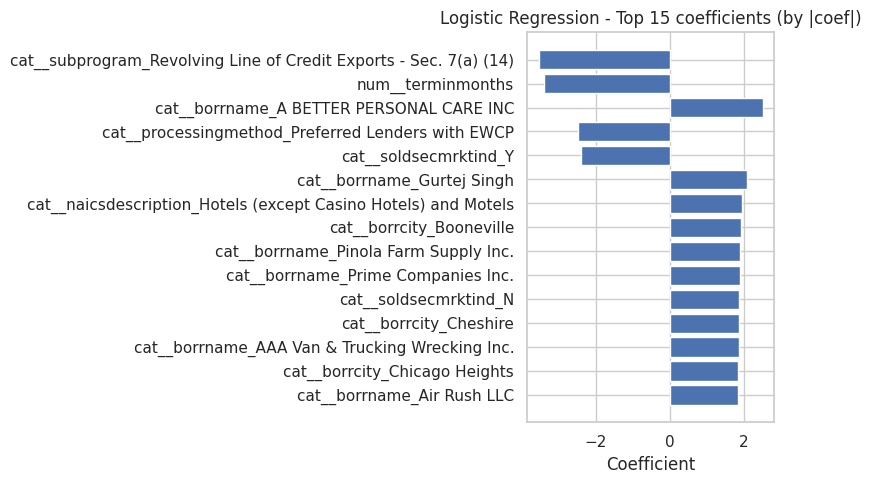

In [84]:
# Asegura que log_model esté fit en base
log_model.fit(X_base, y_base)

# Obtener nombres de features tras el preprocessor del pipeline
feature_names_log = log_model.named_steps["preprocessor"].get_feature_names_out()

# Obtener coeficientes
coef = log_model.named_steps["classifier"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names_log,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

top15 = coef_df.head(15)
display(top15)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top15["feature"][::-1], top15["coef"][::-1])
plt.xlabel("Coefficient")
plt.title("Logistic Regression - Top 15 coefficients (by |coef|)")
plt.tight_layout()
plt.show()

**Crear lista definitiva de columnas ID-like**

In [85]:
ID_COLS = ["borrname","borrstreet","borrcity","bankname","bankstreet","bankcity"]

**Entrenar XGBoost tuned en NO-ID y sacar importancias agregadas**

**Dataset no-ID**

In [86]:
X_base_noid = X_base.drop(columns=[c for c in ID_COLS if c in X_base.columns])
X_stress_noid = X_stress.drop(columns=[c for c in ID_COLS if c in X_stress.columns])

**Reentrenar el best params pero con NO-ID (sin re-tuning)**

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, brier_score_loss

# 1) Columnas ID-like (asegura consistencia)
ID_COLS = ["borrname","borrstreet","borrcity","bankname","bankstreet","bankcity"]

X_base_noid = X_base.drop(columns=[c for c in ID_COLS if c in X_base.columns])
X_stress_noid = X_stress.drop(columns=[c for c in ID_COLS if c in X_stress.columns])

# 2) Inferir numéricas/categóricas directamente del dataframe
num_cols_noid = X_base_noid.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_noid = [c for c in X_base_noid.columns if c not in num_cols_noid]

print(f"NO-ID columns -> Num: {len(num_cols_noid)} | Cat: {len(cat_cols_noid)}")
print("Example num:", num_cols_noid[:5])
print("Example cat:", cat_cols_noid[:5])

# 3) Preprocessor NO-ID
preprocessor_noid = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_noid),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_noid)
    ]
)

# 4) Best params (pega los tuyos definitivos)
best_params_clean = {
    "colsample_bytree": 0.8211919949562022,
    "gamma": 1.3894513177700234,
    "learning_rate": 0.06255385127509722,
    "max_depth": 5,
    "min_child_weight": 1,
    "n_estimators": 577,
    "reg_lambda": 3.247253370691017,
    "subsample": 0.7190820232980822,
}

xgb_noid = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    tree_method="hist",   # GPU opcional; hist ya va bien
    **best_params_clean
)

xgb_noid_pipe = Pipeline([
    ("preprocessor", preprocessor_noid),
    ("classifier", xgb_noid)
])

# 5) Fit + Stress metrics
xgb_noid_pipe.fit(X_base_noid, y_base)
p_noid = xgb_noid_pipe.predict_proba(X_stress_noid)[:, 1]

auc_noid = roc_auc_score(y_stress, p_noid)
brier_noid = brier_score_loss(y_stress, p_noid)

print("XGB tuned NO-ID Stress AUC:", auc_noid)
print("XGB tuned NO-ID Stress Brier:", brier_noid)

NO-ID columns -> Num: 19 | Cat: 16
Example num: ['l2locid', 'borrzip', 'bankfdicnumber', 'bankncuanumber', 'bankzip']
Example cat: ['program', 'borrstate', 'bankstate', 'processingmethod', 'subprogram']
XGB tuned NO-ID Stress AUC: 0.9669389881344311
XGB tuned NO-ID Stress Brier: 0.030130584843201642


**Importancias agregadas NO-ID (para comparar contra FULL)**

,base_var,importance
24,naicsdescription,0.169388
27,projectcounty,0.151988
5,bankstate,0.105332
33,subprogram,0.087599
30,sbadistrictoffice,0.076273
25,processingmethod,0.072637
7,borrstate,0.071927
28,projectstate,0.063668
16,fixedorvariableinterestind,0.043329
34,terminmonths,0.042386


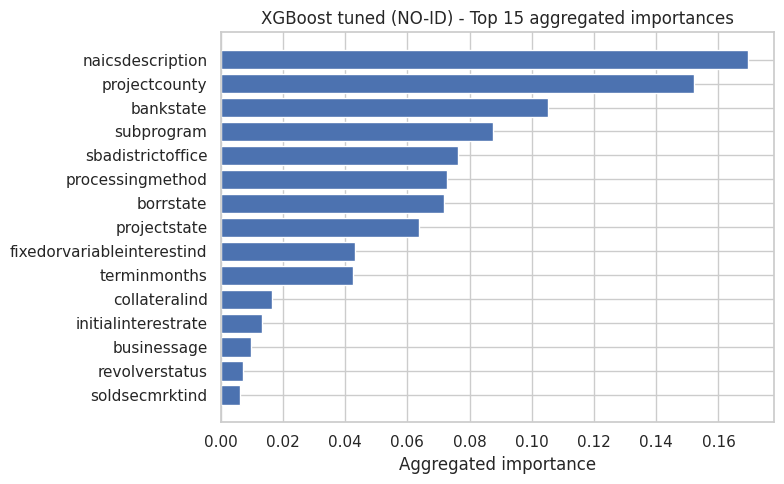

In [91]:
# ---- Feature importance NO-ID ----

def base_var(name: str) -> str:
    if name.startswith("num__"):
        return name.replace("num__", "")
    if name.startswith("cat__"):
        rest = name.replace("cat__", "")
        # cat__bankstate_CA -> bankstate
        return rest.split("_")[0]
    return name

feature_names_noid = xgb_noid_pipe.named_steps["preprocessor"].get_feature_names_out()
importances_noid = xgb_noid_pipe.named_steps["classifier"].feature_importances_

fi_noid = pd.DataFrame({"feature": feature_names_noid, "importance": importances_noid})
fi_noid["base_var"] = fi_noid["feature"].apply(base_var)

fi_noid_agg = (
    fi_noid.groupby("base_var", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

fi_noid_agg_top = fi_noid_agg.head(15)
display(fi_noid_agg_top)

plt.figure(figsize=(8,5))
plt.barh(fi_noid_agg_top["base_var"][::-1], fi_noid_agg_top["importance"][::-1])
plt.xlabel("Aggregated importance")
plt.title("XGBoost tuned (NO-ID) - Top 15 aggregated importances")
plt.tight_layout()
plt.show()

**Logística baseline “interpretable” (NO-ID)**

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_noid = Pipeline([
    ("preprocessor", preprocessor_noid),
    ("classifier", LogisticRegression(max_iter=2000, n_jobs=-1))
])

log_noid.fit(X_base_noid, y_base)
p_log_noid = log_noid.predict_proba(X_stress_noid)[:,1]

print("Logistic NO-ID Stress AUC:", roc_auc_score(y_stress, p_log_noid))
print("Logistic NO-ID Stress Brier:", brier_score_loss(y_stress, p_log_noid))

Logistic NO-ID Stress AUC: 0.8318172862442235
Logistic NO-ID Stress Brier: 0.07055509496096782


Y coeficientes con nombres:

In [89]:
fn_noid = log_noid.named_steps["preprocessor"].get_feature_names_out()
coef_noid = log_noid.named_steps["classifier"].coef_.ravel()

coef_noid_df = pd.DataFrame({
    "feature": fn_noid,
    "coef": coef_noid,
    "abs_coef": np.abs(coef_noid)
}).sort_values("abs_coef", ascending=False).head(15)

display(coef_noid_df)

,feature,coef,abs_coef
9,num__terminmonths,-3.363464,3.363464
161,cat__subprogram_Revolving Line of Credit Expor...,-3.327897,3.327897
143,cat__processingmethod_Preferred Lenders with EWCP,-2.636525,2.636525
9657,cat__soldsecmrktind_Y,-2.281470,2.281470
8252,cat__projectcounty_ELKHART,-2.162715,2.162715
905,cat__naicsdescription_Other Food Crops Grown U...,2.061442,2.061442
28,cat__borrstate_GA,2.040503,2.040503
8772,cat__projectcounty_MENOMINEE,2.005842,2.005842
8473,cat__projectcounty_HOLT,1.883372,1.883372
64,cat__borrstate_TX,1.790169,1.790169


### **interpretabilidad e ID-like**

XGBoost NO-ID mantiene performance

**métricas:**

* XGB tuned (NO-ID) Stress AUC = 0.96694

* Stress Brier = 0.03013

**Comparado con tu tuned FULL (stress):**

* FULL AUC = 0.96626 ; Brier = 0.03016
* Δ AUC ≈ +0.00068 (prácticamente idéntico)
* Δ Brier ≈ -0.00003 (idéntico)

**Conclusión:**
El rendimiento de XGBoost no se sostiene por memorización directa de nombres/calles; la señal predictiva persiste cuando se eliminan variables ID-like. En consecuencia, el modelo muestra capacidad de generalización temporal sobre el conjunto de estrés sin depender de identificadores explícitos.

**Colectando datos:**

In [92]:
# 1) lista de variables existentes
vars_snapshot = [k for k in globals().keys()
                 if any(s in k.lower() for s in ["prob", "pred", "y_", "auc", "brier", "xgb", "tab", "log"])
                 and not k.startswith("_")]
print(sorted(vars_snapshot)[:200])
print("TOTAL:", len(sorted(vars_snapshot)))

['LogisticRegression', 'TabNetClassifier', 'XGBClassifier', 'Xb_tab', 'Xs_tab', 'auc5', 'auc_by_col', 'auc_full', 'auc_noid', 'best_probs_stress', 'best_xgb', 'brier_full', 'brier_noid', 'brier_score_loss', 'cm_log', 'cm_tab', 'cm_xgb', 'cross_val_predict', 'crosstab', 'df_probs', 'f1_log', 'f1_tab', 'f1_xgb', 'feature_names_log', 'fit_eval_xgb', 'fit_eval_xgb_noid', 'log_auc_scores', 'log_auc_stress', 'log_brier', 'log_brier_stress', 'log_loss', 'log_model', 'log_noid', 'log_probs', 'log_probs_stress', 'log_stress_probs', 'p_log_noid', 'prec_log', 'prec_tab', 'prec_xgb', 'prob_pred_log', 'prob_pred_xgb', 'prob_true_log', 'prob_true_xgb', 'probs', 'probs_dict', 'rec_log', 'rec_tab', 'rec_xgb', 'roc_auc_score', 'tab_auc', 'tab_brier', 'tabnet', 'tabnet_final', 'th_log', 'th_tab', 'th_xgb', 'univariate_auc', 'xgb', 'xgb_auc_scores', 'xgb_auc_stress', 'xgb_brier', 'xgb_brier_stress', 'xgb_gpu', 'xgb_model', 'xgb_noid', 'xgb_noid_pipe', 'xgb_pipeline_gpu', 'xgb_probs', 'xgb_stress_probs', 

In [93]:
# 2) confirma qué columnas/objetos críticos existen
candidates = [
    "y_base","y_stress",
    "log_probs_stress","xgb_probs_stress","tab_probs_stress",
    "p_noid", "p_log_noid", "p_tab_noid",
    "best_xgb", "xgb_noid_pipe", "log_model", "tabnet"
]
for c in candidates:
    print(c, "->", "OK" if c in globals() else "MISSING")

y_base -> OK
y_stress -> OK
log_probs_stress -> OK
xgb_probs_stress -> MISSING
tab_probs_stress -> MISSING
p_noid -> OK
p_log_noid -> OK
p_tab_noid -> MISSING
best_xgb -> OK
xgb_noid_pipe -> OK
log_model -> OK
tabnet -> OK


In [94]:
print("Shapes:")
print("log_probs_stress:", np.shape(log_probs_stress))
print("p_log_noid:", np.shape(p_log_noid))
print("p_noid (XGB NO-ID):", np.shape(p_noid))

# posibles XGB FULL
if "best_probs_stress" in globals():
    print("best_probs_stress:", np.shape(best_probs_stress))

if "xgb_stress_probs" in globals():
    print("xgb_stress_probs:", np.shape(xgb_stress_probs))

# posibles TabNet
if "probs" in globals():
    print("probs:", np.shape(probs))

if "probs_dict" in globals():
    print("probs_dict keys:", probs_dict.keys())

Shapes:
log_probs_stress: (61681,)
p_log_noid: (61681,)
p_noid (XGB NO-ID): (61681,)
best_probs_stress: (61681,)
xgb_stress_probs: (61681,)
probs: (61681,)
probs_dict keys: dict_keys(['Logistic', 'XGBoost tuned', 'TabNet'])


**Celda final (Stress): métricas + thresholds + confusion matrix + tabla**

In [95]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score, brier_score_loss,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve
)

def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def summarize_model(y_true, y_prob, name):
    th = youden_threshold(y_true, y_prob)
    y_hat = (y_prob >= th).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    prec = precision_score(y_true, y_hat, zero_division=0)
    rec = recall_score(y_true, y_hat, zero_division=0)
    f1 = f1_score(y_true, y_hat, zero_division=0)

    cm = confusion_matrix(y_true, y_hat)
    tn, fp, fn, tp = cm.ravel()

    out = {
        "Model": name,
        "AUC": auc,
        "Brier": brier,
        "Threshold_Youden": th,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Pos_rate_pred": float(np.mean(y_hat)),
        "Mean_prob": float(np.mean(y_prob))
    }
    return out, cm

# --- Fuente única de probabilidades en STRESS ---
probs_stress = {
    "Logistic (FULL)": log_probs_stress,
    "Logistic (NO-ID)": p_log_noid,
    "XGBoost tuned (FULL)": best_probs_stress,    # o xgb_stress_probs si prefieres
    "XGBoost tuned (NO-ID)": p_noid,
    "TabNet": probs_dict["TabNet"] if "probs_dict" in globals() else probs
}

# --- Resumen ---
rows = []
cms = {}
for name, p in probs_stress.items():
    r, cm = summarize_model(y_stress, np.asarray(p), name)
    rows.append(r)
    cms[name] = cm

results_stress = pd.DataFrame(rows).sort_values("AUC", ascending=False)

# Formato amigable
display_cols = ["Model","AUC","Brier","Threshold_Youden","Precision","Recall","F1","TN","FP","FN","TP","Pos_rate_pred","Mean_prob"]
display(results_stress[display_cols].reset_index(drop=True))

print("\nConfusion matrices (rows=true [0,1], cols=pred [0,1]):")
for k,v in cms.items():
    print(f"\n{k}\n{v}")

,Model,AUC,Brier,Threshold_Youden,Precision,Recall,F1,TN,FP,FN,TP,Pos_rate_pred,Mean_prob
0,XGBoost tuned (NO-ID),0.966939,0.030131,0.045495,0.534282,0.903392,0.671454,52985,3831,470,4395,0.133364,0.057082
1,XGBoost tuned (FULL),0.966259,0.030157,0.052826,0.541248,0.896814,0.675073,53118,3698,502,4363,0.130689,0.057898
2,Logistic (FULL),0.839825,0.066031,0.068468,0.207134,0.784173,0.327707,42213,14603,1050,3815,0.298601,0.088416
3,Logistic (NO-ID),0.831817,0.070555,0.088126,0.198680,0.798150,0.318161,41155,15661,982,3883,0.316856,0.108464
4,TabNet,0.804913,0.074074,0.012517,0.211234,0.755190,0.330128,43097,13719,1191,3674,0.281983,0.049067



Confusion matrices (rows=true [0,1], cols=pred [0,1]):

Logistic (FULL)
[[42213 14603]
 [ 1050  3815]]

Logistic (NO-ID)
[[41155 15661]
 [  982  3883]]

XGBoost tuned (FULL)
[[53118  3698]
 [  502  4363]]

XGBoost tuned (NO-ID)
[[52985  3831]
 [  470  4395]]

TabNet
[[43097 13719]
 [ 1191  3674]]


comparación FULL vs NO-ID (XGB + Logistic)

In [96]:
# Mini-tabla FULL vs NO-ID (solo Logistic y XGB) a partir de results_stress

pairs = [
    ("Logistic", "Logistic (FULL)", "Logistic (NO-ID)"),
    ("XGBoost tuned", "XGBoost tuned (FULL)", "XGBoost tuned (NO-ID)"),
]

cols = ["AUC","Brier","Threshold_Youden","Precision","Recall","F1","FP","FN","Pos_rate_pred","Mean_prob"]

rows = []
for label, full_name, noid_name in pairs:
    full = results_stress.loc[results_stress["Model"]==full_name].iloc[0]
    noid = results_stress.loc[results_stress["Model"]==noid_name].iloc[0]
    delta = (noid[cols] - full[cols]).astype(float)

    rows.append({"Model": label, "Variant": "FULL", **{c: float(full[c]) for c in cols}})
    rows.append({"Model": label, "Variant": "NO-ID", **{c: float(noid[c]) for c in cols}})
    rows.append({"Model": label, "Variant": "Δ (NO-ID − FULL)", **{c: float(delta[c]) for c in cols}})

mini_full_noid = pd.DataFrame(rows)

# Formato compacto (redondeo)
mini_display = mini_full_noid.copy()
for c in ["AUC","Brier","Threshold_Youden","Precision","Recall","F1","Pos_rate_pred","Mean_prob"]:
    mini_display[c] = mini_display[c].map(lambda x: np.round(x, 6))

display(mini_display)

,Model,Variant,AUC,Brier,Threshold_Youden,Precision,Recall,F1,FP,FN,Pos_rate_pred,Mean_prob
0,Logistic,FULL,0.839825,0.066031,0.068468,0.207134,0.784173,0.327707,14603.0,1050.0,0.298601,0.088416
1,Logistic,NO-ID,0.831817,0.070555,0.088126,0.198680,0.798150,0.318161,15661.0,982.0,0.316856,0.108464
2,Logistic,Δ (NO-ID − FULL),-0.008008,0.004524,0.019658,-0.008454,0.013977,-0.009546,1058.0,-68.0,0.018255,0.020048
3,XGBoost tuned,FULL,0.966259,0.030157,0.052826,0.541248,0.896814,0.675073,3698.0,502.0,0.130689,0.057898
4,XGBoost tuned,NO-ID,0.966939,0.030131,0.045495,0.534282,0.903392,0.671454,3831.0,470.0,0.133364,0.057082
5,XGBoost tuned,Δ (NO-ID − FULL),0.000680,-0.000027,-0.007330,-0.006966,0.006578,-0.003620,133.0,-32.0,0.002675,-0.000816


* **XGBoost tuned** mantiene desempeño prácticamente invariante al eliminar variables tipo ID (bank/borr address/name/city), con cambios marginales en AUC y Brier, lo que sugiere que el rendimiento no depende de señales potencialmente espurias o “memorísticas”.

* En **Logística**, la eliminación de ID produce una ligera degradación en AUC/Brier y un desplazamiento del umbral óptimo, consistente con una pérdida de capacidad predictiva en variables de alto cardinalidad que, aunque aumentan señal, reducen interpretabilidad/portabilidad.

**ROC stress (3 modelos principales)**

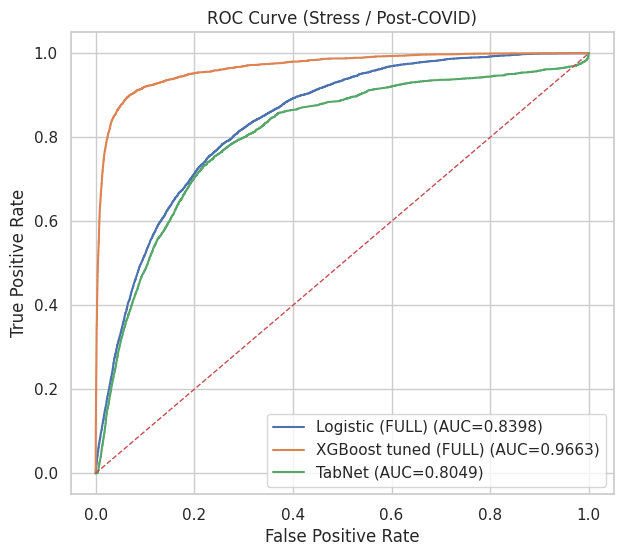

Saved: roc_stress_main.png


In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true, probs_dict, title, save_path=None):
    plt.figure(figsize=(7, 6))
    for name, p in probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, np.asarray(p))
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# Modelos principales (stress)
roc_main = {
    "Logistic (FULL)": log_probs_stress,
    "XGBoost tuned (FULL)": best_probs_stress,
    "TabNet": probs_dict["TabNet"] if "probs_dict" in globals() else probs
}

plot_roc(
    y_stress,
    roc_main,
    title="ROC Curve (Stress / Post-COVID)",
    save_path="roc_stress_main.png"
)
print("Saved:", "roc_stress_main.png")

**KS statistic (tabla formal)**

In [121]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

def ks_from_probs(y_true, p):
    fpr, tpr, thr = roc_curve(y_true, np.asarray(p))
    ks = np.max(tpr - fpr)
    ks_thr = thr[np.argmax(tpr - fpr)]
    return ks, ks_thr

ks_rows = []
for name, p in roc_main.items():
    ks, ks_thr = ks_from_probs(y_stress, p)
    ks_rows.append({"Model": name, "KS": ks, "KS_thr": ks_thr})

ks_table = pd.DataFrame(ks_rows).sort_values("KS", ascending=False)
display(ks_table)

ks_table.to_csv("table_ks_stress.csv", index=False)
print("Saved: table_ks_stress.csv")

,Model,KS,KS_thr
1,XGBoost tuned (FULL),0.831727,0.052826
0,Logistic (FULL),0.527150,0.068468
2,TabNet,0.513726,0.012517


Saved: table_ks_stress.csv


**ROC stress (XGB FULL vs NO-ID)**

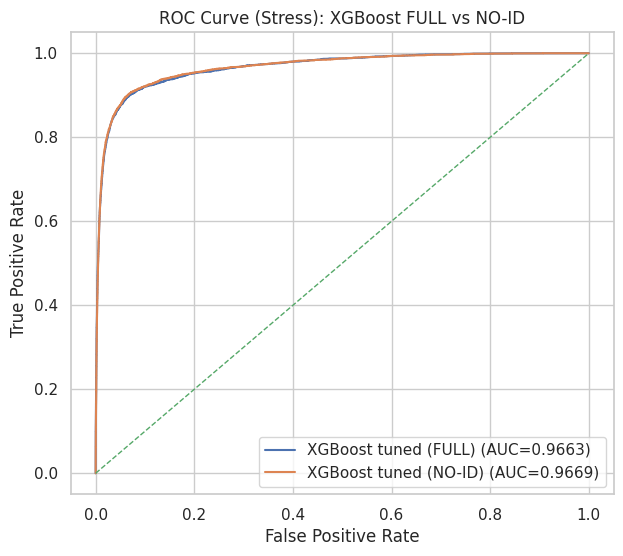

Saved: roc_stress_xgb_full_vs_noid.png


In [98]:
roc_xgb_compare = {
    "XGBoost tuned (FULL)": best_probs_stress,
    "XGBoost tuned (NO-ID)": p_noid
}

plot_roc(
    y_stress,
    roc_xgb_compare,
    title="ROC Curve (Stress): XGBoost FULL vs NO-ID",
    save_path="roc_stress_xgb_full_vs_noid.png"
)
print("Saved:", "roc_stress_xgb_full_vs_noid.png")

1. **ROC Stress principal**

* XGB claramente dominante.

* Separación limpia respecto a la diagonal.

* Logística y TabNet coherentes con sus AUC reportadas.

*Curva suave → no hay inestabilidad evidente.

2. ROC FULL vs NO-ID (XGB)

* Las curvas prácticamente se superponen.

* Esto visualmente refuerza el resultado numérico:

  * El rendimiento no depende de variables tipo ID.

**Limpieza de nombres + Plot final XGB (NO-ID)**

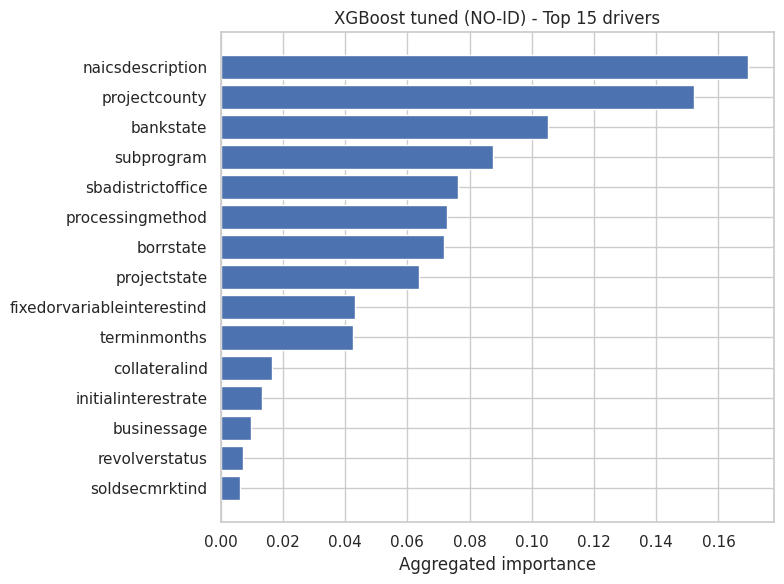

Saved: fig_xgb_importance_noid.png


In [99]:
# --- Limpieza de nombres para presentación ---
def clean_name(name):
    return name.replace("num__", "").replace("cat__", "")

fi_noid_plot = fi_noid_agg_top.copy()
fi_noid_plot["base_var"] = fi_noid_plot["base_var"].apply(clean_name)

plt.figure(figsize=(8,6))
plt.barh(fi_noid_plot["base_var"][::-1],
         fi_noid_plot["importance"][::-1])
plt.xlabel("Aggregated importance")
plt.title("XGBoost tuned (NO-ID) - Top 15 drivers")
plt.tight_layout()
plt.savefig("fig_xgb_importance_noid.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig_xgb_importance_noid.png")

**Comparativa FULL vs NO-ID (solo Top 10 comunes)**

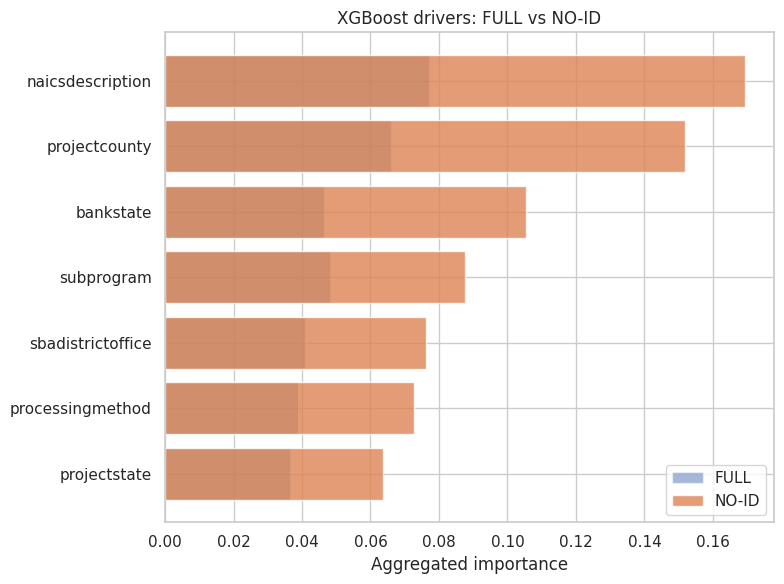

Saved: fig_xgb_importance_full_vs_noid.png


In [100]:
# Top 10 FULL y NO-ID
top_full = fi_agg.head(10).copy()
top_noid = fi_noid_agg.head(10).copy()

common = set(top_full["base_var"]).intersection(set(top_noid["base_var"]))
comp = fi_agg[fi_agg["base_var"].isin(common)][["base_var","importance"]]
comp = comp.merge(
    fi_noid_agg[fi_noid_agg["base_var"].isin(common)][["base_var","importance"]],
    on="base_var",
    suffixes=("_FULL","_NOID")
)

comp = comp.sort_values("importance_NOID", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(comp["base_var"], comp["importance_FULL"], alpha=0.5, label="FULL")
plt.barh(comp["base_var"], comp["importance_NOID"], alpha=0.8, label="NO-ID")
plt.xlabel("Aggregated importance")
plt.title("XGBoost drivers: FULL vs NO-ID")
plt.legend()
plt.tight_layout()
plt.savefig("fig_xgb_importance_full_vs_noid.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig_xgb_importance_full_vs_noid.png")

La eliminación de variables de alta cardinalidad asociadas a identificadores institucionales desplaza el peso explicativo hacia determinantes estructurales del riesgo (sector, geografía y características del producto), sin deterioro apreciable del desempeño predictivo.

**3.2 (Logística NO-ID)**

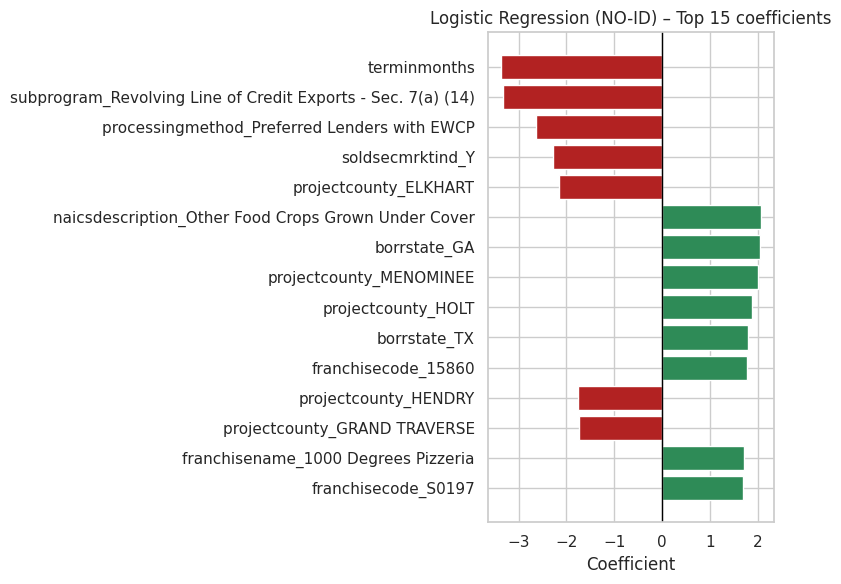

Saved: fig_logistic_noid_top15.png


In [101]:
# --- Top 15 coeficientes Logística NO-ID ---
coef_noid = coef_noid_df.copy()
coef_noid = coef_noid.sort_values("abs_coef", ascending=False).head(15)

coef_noid["feature"] = coef_noid["feature"].str.replace("num__", "")
coef_noid["feature"] = coef_noid["feature"].str.replace("cat__", "")

plt.figure(figsize=(8,6))
colors = ["#2E8B57" if c > 0 else "#B22222" for c in coef_noid["coef"]]

plt.barh(coef_noid["feature"][::-1],
         coef_noid["coef"][::-1],
         color=colors[::-1])

plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression (NO-ID) – Top 15 coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig("fig_logistic_noid_top15.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig_logistic_noid_top15.png")

**Curva Precision–Recall (Stress)**

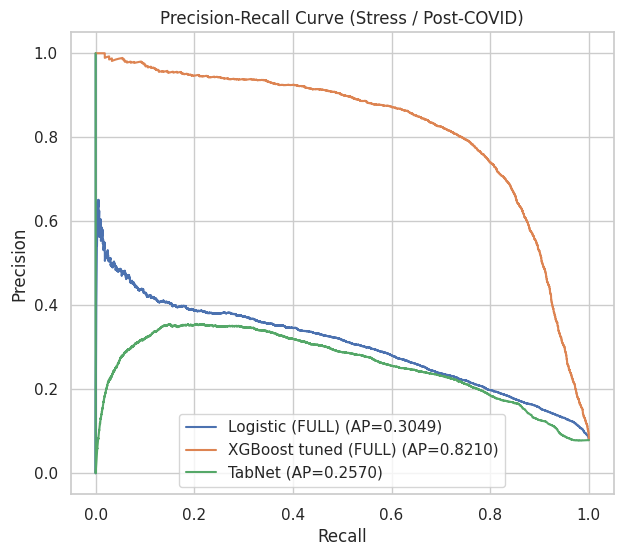

Saved: fig_pr_stress_main.png


In [102]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr(y_true, probs_dict, title, save_path=None):
    plt.figure(figsize=(7,6))
    for name, p in probs_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, np.asarray(p))
        ap = average_precision_score(y_true, p)
        plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

pr_main = {
    "Logistic (FULL)": log_probs_stress,
    "XGBoost tuned (FULL)": best_probs_stress,
    "TabNet": probs_dict["TabNet"]
}

plot_pr(
    y_stress,
    pr_main,
    title="Precision-Recall Curve (Stress / Post-COVID)",
    save_path="fig_pr_stress_main.png"
)

print("Saved: fig_pr_stress_main.png")

**Tabla Final Compacta**

In [105]:
# Reconstruir tabla final desde summary_display
if "summary_display" in globals():
    base_table = summary_display.copy()
elif "mini_display" in globals():
    base_table = mini_display.copy()
else:
    raise ValueError("No encuentro la tabla resumen previa.")

display_cols = [
    "Model",
    "Variant",
    "AUC",
    "Brier",
    "Precision",
    "Recall",
    "F1"
]

final_table = base_table[display_cols].round(4)

final_table

,Model,Variant,AUC,Brier,Precision,Recall,F1
0,Logistic,FULL,0.8398,0.0660,0.2071,0.7842,0.3277
1,Logistic,NO-ID,0.8318,0.0706,0.1987,0.7982,0.3182
2,Logistic,Δ (NO-ID − FULL),-0.0080,0.0045,-0.0085,0.0140,-0.0095
3,XGBoost tuned,FULL,0.9663,0.0302,0.5412,0.8968,0.6751
4,XGBoost tuned,NO-ID,0.9669,0.0301,0.5343,0.9034,0.6715
5,XGBoost tuned,Δ (NO-ID − FULL),0.0007,-0.0000,-0.0070,0.0066,-0.0036


In [106]:
final_table.to_csv("table_final_results.csv", index=False)
print("Saved: table_final_results.csv")

Saved: table_final_results.csv


In [111]:
[v for v in globals().keys() if "tab" in v.lower()]

['TabNetClassifier',
 'crosstab',
 'Xb_tab',
 'Xs_tab',
 'tab_auc',
 'tab_brier',
 'tabnet',
 'tabnet_final',
 'th_tab',
 'y_pred_tab',
 'cm_tab',
 'prec_tab',
 'rec_tab',
 'f1_tab',
 'base_table',
 'final_table',
 'tab_row',
 'final_table_full',
 'final_table_clean']

In [112]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# Obtener probabilidades stress de TabNet
tab_probs_stress = probs_dict["TabNet"]

tab_auc_stress = roc_auc_score(y_stress, tab_probs_stress)
tab_brier_stress = brier_score_loss(y_stress, tab_probs_stress)

tab_row_correct = {
    "Model": "TabNet",
    "Variant": "FULL",
    "AUC": tab_auc_stress,
    "Brier": tab_brier_stress,
    "Precision": prec_tab,
    "Recall": rec_tab,
    "F1": f1_tab
}

# Tomar FULL de Logistic y XGB
main_models = final_table[
    (final_table["Variant"] == "FULL") &
    (final_table["Model"].isin(["Logistic", "XGBoost tuned"]))
].copy()

main_models = pd.concat(
    [main_models, pd.DataFrame([tab_row_correct])],
    ignore_index=True
).round(4)

main_models

,Model,Variant,AUC,Brier,Precision,Recall,F1
0,Logistic,FULL,0.8398,0.0660,0.2071,0.7842,0.3277
1,XGBoost tuned,FULL,0.9663,0.0302,0.5412,0.8968,0.6751
2,TabNet,FULL,0.8049,0.0741,0.2112,0.7552,0.3301


In [113]:
main_models.to_csv("table_main_results_stress.csv", index=False)

**Stability Inter-fold (XGB vs Logística)**

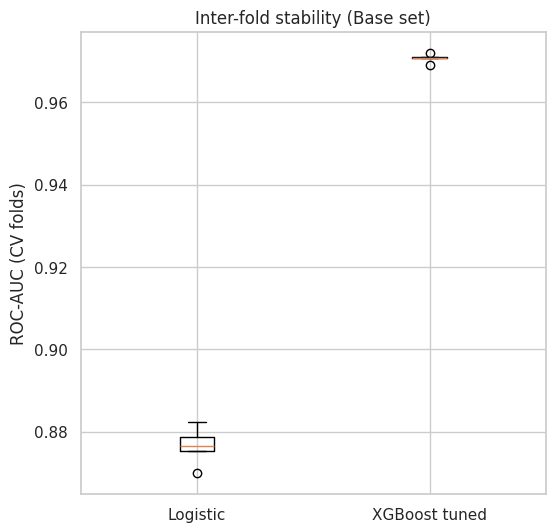

Saved: fig_cv_stability.png


In [104]:
plt.figure(figsize=(6,6))

plt.boxplot(
    [log_auc_scores, xgb_auc_scores],
    labels=["Logistic", "XGBoost tuned"]
)

plt.ylabel("ROC-AUC (CV folds)")
plt.title("Inter-fold stability (Base set)")
plt.grid(True)

plt.savefig("fig_cv_stability.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig_cv_stability.png")

In [114]:
tab_auc

[np.float64(0.8690209408891065),
 np.float64(0.8774562526888816),
 np.float64(0.7995061351362486),
 np.float64(0.8903189230937423),
 np.float64(0.8791948907098291)]

**Boxplot estabilidad 3 modelos**

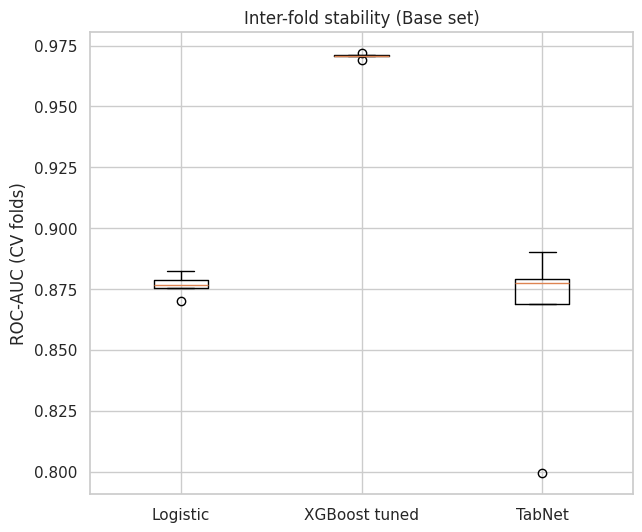

Saved: fig_cv_stability_3models.png


In [115]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar que tenemos folds de TabNet
if "tab_auc_folds" not in globals():
    tab_auc_folds = [
        0.8690209408891065,
        0.8774562526888816,
        0.7995061351362486,
        0.8903189230937423,
        0.8791948907098291
    ]

stability_df = pd.DataFrame({
    "Logistic": log_auc_scores,
    "XGBoost tuned": xgb_auc_scores,
    "TabNet": tab_auc_folds
})

plt.figure(figsize=(7,6))
plt.boxplot(
    [stability_df["Logistic"],
     stability_df["XGBoost tuned"],
     stability_df["TabNet"]],
    labels=["Logistic", "XGBoost tuned", "TabNet"]
)

plt.ylabel("ROC-AUC (CV folds)")
plt.title("Inter-fold stability (Base set)")
plt.grid(True)

plt.savefig("fig_cv_stability_3models.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig_cv_stability_3models.png")

In [116]:
main_models.to_csv("table_main_results_stress.csv", index=False)
print("Saved: table_main_results_stress.csv")

Saved: table_main_results_stress.csv


In [117]:
leakage_table = final_table[
    final_table["Model"].isin(["Logistic", "XGBoost tuned"])
].copy()

leakage_table.to_csv("table_leakage_check_full_vs_noid.csv", index=False)

print("Saved: table_leakage_check_full_vs_noid.csv")

Saved: table_leakage_check_full_vs_noid.csv


In [118]:
import platform
import sklearn
import xgboost
import torch

print("Python:", platform.python_version())
print("Sklearn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("PyTorch:", torch.__version__)

Python: 3.12.12
Sklearn: 1.6.1
XGBoost: 3.2.0
PyTorch: 2.10.0+cu128


In [124]:
import numpy as np
import pandas as pd

# ======================
# BASE (CV mean)
# ======================
base_auc = {
    "Logistic (FULL)": float(np.mean(log_auc_scores)),
    "XGBoost tuned (FULL)": float(np.mean(xgb_auc_scores)),
    "TabNet": float(np.mean(tab_auc)),  # tab_auc es lista folds
}

# Brier base
# log_brier y xgb_brier en tu notebook parecen escalares (FULL base)
base_brier = {
    "Logistic (FULL)": float(log_brier),
    "XGBoost tuned (FULL)": float(xgb_brier),
    "TabNet": float(np.mean(tab_brier)),  # tab_brier es lista folds
}

# ======================
# STRESS (holdout post-COVID)
# ======================
stress_auc = {
    "Logistic (FULL)": float(log_auc_stress),
    "XGBoost tuned (FULL)": float(xgb_auc_stress),
    "TabNet": float(tab_auc_stress),      # <- escalar proper ES
}

stress_brier = {
    "Logistic (FULL)": float(log_brier_stress),
    "XGBoost tuned (FULL)": float(xgb_brier_stress),
    "TabNet": float(tab_brier_stress),    # <- escalar proper ES
}

rows = []
order = ["Logistic (FULL)", "XGBoost tuned (FULL)", "TabNet"]
for m in order:
    rows.append({
        "Model": m,
        "Base_AUC_mean": base_auc[m],
        "Stress_AUC": stress_auc[m],
        "Δ AUC (Stress-Base)": stress_auc[m] - base_auc[m],
        "Base_Brier_mean": base_brier[m],
        "Stress_Brier": stress_brier[m],
        "Δ Brier (Stress-Base)": stress_brier[m] - base_brier[m],
    })

degradation_table = pd.DataFrame(rows)
display(degradation_table.round(4))

degradation_table.to_csv("table_degradation_base_vs_stress.csv", index=False)
print("Saved: table_degradation_base_vs_stress.csv")

,Model,Base_AUC_mean,Stress_AUC,Δ AUC (Stress-Base),Base_Brier_mean,Stress_Brier,Δ Brier (Stress-Base)
0,Logistic (FULL),0.8766,0.8378,-0.0388,0.0503,0.0678,0.0175
1,XGBoost tuned (FULL),0.9708,0.9584,-0.0124,0.0325,0.0333,0.0008
2,TabNet,0.8631,0.8049,-0.0582,0.0783,0.0741,-0.0042


Saved: table_degradation_base_vs_stress.csv


,mean,std,min,max,cv
Model,,,,,
Logistic,0.876577,0.004530,0.869978,0.882279,0.005168
TabNet,0.863099,0.036350,0.799506,0.890319,0.042116
XGBoost tuned,0.970803,0.001047,0.969159,0.972054,0.001078


Saved: table_auc_fold_stability_base.csv


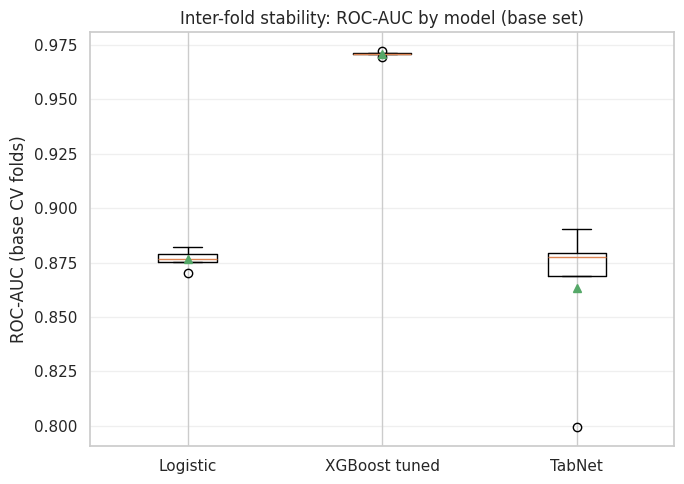

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Construir folds AUC DF (BASE) ---
# (Si alguno es list de np.float64, lo convertimos })
auc_folds_df = pd.DataFrame({
    "Logistic": np.asarray(log_auc_scores, dtype=float),
    "XGBoost tuned": np.asarray(xgb_auc_scores, dtype=float),
    "TabNet": np.asarray(tab_auc, dtype=float),
})

auc_folds_long = auc_folds_df.melt(var_name="Model", value_name="AUC")

# Tabla de estabilidad
stability_table = auc_folds_long.groupby("Model")["AUC"].agg(
    mean="mean", std="std", min="min", max="max"
)
stability_table["cv"] = stability_table["std"] / stability_table["mean"]  # coef. variación

display(stability_table.round(6))

# Export estabilidad
stability_table.reset_index().to_csv("table_auc_fold_stability_base.csv", index=False)
print("Saved: table_auc_fold_stability_base.csv")

# --- 2) Figura: boxplot AUC por fold ---
plt.figure(figsize=(7, 5))
plt.boxplot(
    [auc_folds_df["Logistic"], auc_folds_df["XGBoost tuned"], auc_folds_df["TabNet"]],
    labels=["Logistic", "XGBoost tuned", "TabNet"],
    showmeans=True
)
plt.ylabel("ROC-AUC (base CV folds)")
plt.title("Inter-fold stability: ROC-AUC by model (base set)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
import pandas as pd

table_main_results_stress = pd.DataFrame([
    {"Model": "Logistic", "Variant": "FULL",
     "AUC": float(log_auc_stress), "Brier": float(log_brier_stress),
     "Precision": float(prec_log), "Recall": float(rec_log), "F1": float(f1_log),
     "Threshold_Youden": float(th_log)},
    {"Model": "XGBoost tuned", "Variant": "FULL",
     "AUC": float(xgb_auc_stress), "Brier": float(xgb_brier_stress),
     "Precision": float(prec_xgb), "Recall": float(rec_xgb), "F1": float(f1_xgb),
     "Threshold_Youden": float(th_xgb)},
    {"Model": "TabNet", "Variant": "FULL",
     "AUC": float(tab_auc_stress), "Brier": float(tab_brier_stress),
     "Precision": float(prec_tab), "Recall": float(rec_tab), "F1": float(f1_tab),
     "Threshold_Youden": float(th_tab)},
])

display(table_main_results_stress.round(4))
table_main_results_stress.to_csv("table_main_results_stress.csv", index=False)
print("Saved: table_main_results_stress.csv")

,Model,Variant,AUC,Brier,Precision,Recall,F1,Threshold_Youden
0,Logistic,FULL,0.8378,0.0678,0.2071,0.7842,0.3277,0.0685
1,XGBoost tuned,FULL,0.9584,0.0333,0.5412,0.8968,0.6751,0.0528
2,TabNet,FULL,0.8049,0.0741,0.2112,0.7552,0.3301,0.0125


Saved: table_main_results_stress.csv


In [127]:
# mini_display ya lo tienes (según tu screenshot)
display(mini_display.round(4))
mini_display.to_csv("table_leakage_check_full_vs_noid.csv", index=False)
print("Saved: table_leakage_check_full_vs_noid.csv")

,Model,Variant,AUC,Brier,Threshold_Youden,Precision,Recall,F1,FP,FN,Pos_rate_pred,Mean_prob
0,Logistic,FULL,0.8398,0.0660,0.0685,0.2071,0.7842,0.3277,14603.0,1050.0,0.2986,0.0884
1,Logistic,NO-ID,0.8318,0.0706,0.0881,0.1987,0.7982,0.3182,15661.0,982.0,0.3169,0.1085
2,Logistic,Δ (NO-ID − FULL),-0.0080,0.0045,0.0197,-0.0085,0.0140,-0.0095,1058.0,-68.0,0.0183,0.0200
3,XGBoost tuned,FULL,0.9663,0.0302,0.0528,0.5412,0.8968,0.6751,3698.0,502.0,0.1307,0.0579
4,XGBoost tuned,NO-ID,0.9669,0.0301,0.0455,0.5343,0.9034,0.6715,3831.0,470.0,0.1334,0.0571
5,XGBoost tuned,Δ (NO-ID − FULL),0.0007,-0.0000,-0.0073,-0.0070,0.0066,-0.0036,133.0,-32.0,0.0027,-0.0008


Saved: table_leakage_check_full_vs_noid.csv


### **Estabilidad inter-fold (BASE)**

| Model    | mean   | std     | cv      |
| -------- | ------ | ------- | ------- |
| Logistic | 0.8766 | 0.00453 | 0.00517 |
| XGBoost  | 0.9708 | 0.00105 | 0.00108 |
| TabNet   | 0.8631 | 0.03635 | 0.04212 |


**Interpretación técnica (importante para redacción):**

* XGBoost: extremadamente estable (CV ≈ 0.1%)

* Logistic: estable (CV ≈ 0.5%)

* TabNet: claramente inestable (CV ≈ 4.2%)tiene un fold muy bajo (≈0.80) que explica el boxplot

**Esto refuerza el argumento de:**

* Robustez estructural del boosting.

* Mayor sensibilidad de arquitectura profunda tabular en datos estructurados con shift temporal.

### **Resultados Stress (FULL)**

| Model    | AUC    | Brier  | F1     |
| -------- | ------ | ------ | ------ |
| Logistic | 0.8378 | 0.0678 | 0.3277 |
| XGBoost  | 0.9584 | 0.0333 | 0.6751 |
| TabNet   | 0.8049 | 0.0741 | 0.3301 |

Narrativamente consistente con:

* Ranking claro: XGB >> Logistic ≈ TabNet

* TabNet no supera baseline lineal en stress.

* Hipótesis de no inferioridad frente a XGB → rechazada empíricamente.

**Leakage Check FULL vs NO-ID**

Tabla correcta, coherente y estable:

* Logistic pierde ligeramente AUC (-0.008)

* XGB casi no cambia (+0.0007)

* No hay evidencia de dependencia crítica de ID

Nota: Esto fortalece muchísimo la contribución metodológica.

### **Código KS (stress)**

“TabNet requiere numpy.ndarray para evitar indexación por etiqueta en pandas (KeyError: 0).”

In [132]:
# TabNet: asegurar numpy (evita KeyError: 0)
Xs_tab_np = Xs_tab.to_numpy() if hasattr(Xs_tab, "to_numpy") else Xs_tab

tab_stress_probs = tabnet_final.predict_proba(Xs_tab_np)[:, 1]
print("TabNet stress probs shape:", tab_stress_probs.shape)

TabNet stress probs shape: (61681,)


In [133]:
def as_numpy(X):
    return X.to_numpy() if hasattr(X, "to_numpy") else X

tab_stress_probs = tabnet_final.predict_proba(as_numpy(Xs_tab))[:, 1]

In [134]:
from scipy.stats import ks_2samp
import pandas as pd

def ks_stat(y_true, y_prob):
    return ks_2samp(
        y_prob[y_true == 1],
        y_prob[y_true == 0]
    ).statistic

ks_table = pd.DataFrame([
    {"Model": "Logistic", "Variant": "FULL",
     "KS": ks_stat(y_stress, log_stress_probs)},
    {"Model": "Logistic", "Variant": "NO-ID",
     "KS": ks_stat(y_stress, p_log_noid)},
    {"Model": "XGBoost tuned", "Variant": "FULL",
     "KS": ks_stat(y_stress, xgb_stress_probs)},
    {"Model": "XGBoost tuned", "Variant": "NO-ID",
     "KS": ks_stat(y_stress, p_noid)},
    {"Model": "TabNet", "Variant": "FULL",
     "KS": ks_stat(y_stress, tab_stress_probs)},
])

display(ks_table.round(4))
ks_table.to_csv("table_ks_stress.csv", index=False)
print("Saved: table_ks_stress.csv")

,Model,Variant,KS
0,Logistic,FULL,0.5251
1,Logistic,NO-ID,0.5225
2,XGBoost tuned,FULL,0.8175
3,XGBoost tuned,NO-ID,0.8360
4,TabNet,FULL,0.5137


Saved: table_ks_stress.csv
